<style>
:root { --volix:#7EF3C4; --dark:#101312; --panel:#171b19; --text:#f5fff9; --muted:#a9bbb3; --line:#2d3a35; }
html { scroll-behavior:smooth; }
body { background:var(--dark)!important; color:var(--text)!important; font-family:Inter,Segoe UI,Arial,sans-serif; }
.jp-Notebook { max-width:1320px; margin:0 auto; padding:28px 38px 80px; background:var(--dark)!important; }
.jp-Cell { background:transparent!important; }
.jp-RenderedHTMLCommon, .jp-RenderedHTMLCommon p, .jp-RenderedHTMLCommon li { color:var(--text)!important; line-height:1.65; }
.jp-RenderedHTMLCommon h1, .jp-RenderedHTMLCommon h2, .jp-RenderedHTMLCommon h3 { color:var(--text)!important; scroll-margin-top:20px; }
.jp-RenderedHTMLCommon h2 { border-bottom:2px solid var(--volix); padding-bottom:9px; margin-top:44px; }
.jp-RenderedHTMLCommon h3 { color:var(--volix)!important; margin-top:30px; }
.jp-RenderedHTMLCommon h4 { color:var(--volix)!important; margin-top:22px; font-size:15px; }
.executive-summary { border:3px solid var(--volix); border-radius:12px; padding:38px 42px; margin:12px 0 30px; background:linear-gradient(135deg,#10251f,#121513 70%); }
.executive-summary h1 { font-size:40px; margin:10px 0 8px; }
.executive-summary .lead { color:var(--muted)!important; font-size:19px; max-width:900px; }
.eyebrow { color:var(--volix); font-weight:800; letter-spacing:.15em; text-transform:uppercase; font-size:12px; }
blockquote { border-left:5px solid var(--volix)!important; background:#14211d; padding:14px 20px!important; color:var(--text)!important; }
pre { background:#0c0f0e!important; border:1px solid var(--line)!important; border-left:5px solid var(--volix)!important; color:#dfffee!important; padding:16px!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) { width:100%!important; border-collapse:collapse!important; border:2px solid var(--volix)!important; background:#171a18!important; color:var(--text)!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) th { background:#0e5146!important; color:#fff!important; padding:10px!important; border-bottom:3px solid var(--volix)!important; text-align:left!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) td { background:#171a18!important; color:var(--text)!important; padding:9px 10px!important; border-bottom:1px solid #34403b!important; }
.jp-RenderedHTMLCommon table:not([id^="T_"]) tbody tr:nth-child(even) td { background:#202421!important; }
.dataframe { width:100%!important; border-collapse:collapse!important; border:2px solid var(--volix)!important; font-size:13px; }
.dataframe th { background:#0e5146!important; color:white!important; padding:10px!important; border-bottom:3px solid var(--volix)!important; position:sticky; top:0; }
.dataframe td { background:#171a18!important; color:var(--text)!important; padding:8px 10px!important; border-bottom:1px solid #34403b!important; }
.jp-OutputArea-output img { display:block; max-width:100%; height:auto; margin:20px auto 10px; border-radius:4px; }
.jp-OutputArea { overflow-x:auto; }
a { color:var(--volix)!important; }
.warn-box { border:2px solid #FFD166; background:rgba(255,209,102,.08); border-radius:8px; padding:14px 18px; margin:14px 0; }
.warn-box b { color:#FFD166; text-transform:uppercase; font-size:11px; letter-spacing:.1em; display:block; margin-bottom:6px; }
@media print { body,.jp-Notebook{background:#fff!important;color:#111!important}.jp-RenderedHTMLCommon p,.jp-RenderedHTMLCommon li,.jp-RenderedHTMLCommon h1,.jp-RenderedHTMLCommon h2{color:#111!important}.jp-Cell{break-inside:avoid}.executive-summary{background:#fff!important}.dataframe td,.jp-RenderedHTMLCommon table:not([id^="T_"]) td{background:#fff!important;color:#111!important}.jp-RenderedHTMLCommon table:not([id^="T_"]) th{color:#fff!important} }
</style>

<div class="executive-summary">
<div class="eyebrow">Relatório técnico · Setembro de 2026</div>
<h1>Segmentação de Clientes — Vibra Lubrax</h1>
<p class="lead">Como chegamos de um primeiro teste estatisticamente enganoso até uma segmentação de 5
clusters validada, e como ela foi enriquecida com família de produto e frequência de compra para
virar uma base de pricing. Escrito para qualquer analista de dados entender o raciocínio e reproduzir
os resultados.</p>
</div>

## Resumo executivo

Testamos 5 configurações de clusterização (K-Means) até chegar num resultado ao mesmo tempo
estatisticamente aceitável e útil para negócio:

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display, Image

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUTPUTS = ROOT / 'outputs'
CLUSTER = OUTPUTS / '2. Clusterização'
EDA_DIR = OUTPUTS / '1. EDA'
FIGS = CLUSTER / '4.apresentacao'

comparativo = pd.read_csv(CLUSTER / 'comparativo_testes_kmeans.csv')
tabela_resumo = comparativo[['teste', 'k', 'n_features', 'silhueta', 'davies_bouldin', 'maior_cluster_%', 'menor_cluster_%']].copy()
tabela_resumo.columns = ['Teste', 'k', 'Nº features', 'Silhueta', 'Davies-Bouldin', 'Maior cluster %', 'Menor cluster %']
display(tabela_resumo)

,Teste,k,Nº features,Silhueta,Davies-Bouldin,Maior cluster %,Menor cluster %
0,Teste 1,2,5,0.9588,0.4414,99.8,0.2
1,Teste 2,4,5,0.3570,1.0400,69.2,2.8
2,Teste 3,5,5,0.2548,1.0968,50.9,2.7
3,Teste 4,4,6,0.3368,1.0821,67.2,3.0
4,Teste 5,5,6,0.3014,1.1413,56.7,1.8


O **Teste 5** (k=5, 6 features) foi o escolhido: silhueta 0,30 e Davies-Bouldin 1,14 — ambos
"aceitáveis", não "excelentes" — mas com distribuição de clientes por cluster realista (o maior
cluster tem 56,7% da base, o menor 1,8%), diferente do Teste 1, cuja silhueta "excelente" (0,96)
escondia uma divisão inútil de 99,8% contra 0,2%. As seções seguintes explicam esse raciocínio passo
a passo.

> **Como usar este relatório:** cada seção pode ser lida isoladamente. Se você só quer o resultado
> final, vá direto à seção 5. Se quer entender por que confiar (ou desconfiar) das métricas, leia a
> seção 3 antes.

## 1. Objetivo e escopo da análise

**Pergunta de negócio:** existem grupos de clientes suficientemente diferentes entre si para
justificar uma política de pricing diferenciada (em vez de um preço único para toda a base)?

**Abordagem:** clusterização não-supervisionada (K-Means) sobre features de comportamento de compra
por cliente — não existe uma "resposta certa" pré-rotulada; o algoritmo encontra agrupamentos a
partir da estrutura dos próprios dados, e cabe à análise (e depois ao negócio) validar se os grupos
encontrados fazem sentido.

**Escopo dos dados:**

In [2]:
df_raw = pd.read_pickle(OUTPUTS / 'cache' / 'base_Lubrax_origem.pkl')
print(f"Transações brutas: {len(df_raw):,}")
print(f"Colunas: {df_raw.shape[1]}")
print(f"Período real dos dados: {df_raw['Data Venda'].min():%d/%m/%Y} a {df_raw['Data Venda'].max():%d/%m/%Y}")

Transações brutas: 253,624
Colunas: 110
Período real dos dados: 01/01/2023 a 01/09/2026


## 2. Dados e preparação

### 2.1 Classificar o que é venda de verdade

A base bruta mistura vendas, devoluções, ajustes contábeis sem movimento físico e alguns registros
com sinais inconsistentes. Antes de qualquer agregação, cada linha é classificada — a regra usada no
`1.EDA_Kmeans.ipynb` (e repetida aqui) é simples: **é venda quando volume e receita líquida são ambos
positivos**.

In [3]:
EPS = 1e-6
volume = pd.to_numeric(df_raw['Volume'], errors='coerce')
receita_liquida = pd.to_numeric(df_raw['Receita líquida'], errors='coerce')
venda = volume.gt(EPS) & receita_liquida.gt(EPS)
print(f"Vendas elegíveis: {venda.sum():,} de {len(df_raw):,} linhas ({venda.mean()*100:.1f}%)")

Vendas elegíveis: 245,456 de 253,624 linhas (96.8%)


### 2.2 Agregar por cliente

As vendas elegíveis são agregadas por `Código Cliente`, virando uma linha por cliente com métricas
como volume total, preço ponderado (**sempre** soma(receita)/soma(volume), nunca média de preços por
linha — médias simples de preço distorcem o resultado quando o volume por transação varia muito),
margem percentual ponderada, frequência mensal, taxa de devolução e diversidade de produtos
comprados. Esse dataset (`outputs/1. EDA/kmeans_clientes_features.pkl`) tem **7.507 clientes e
22 colunas**.

### 2.3 Cortar outliers antes de normalizar

Antes de rodar o K-Means, cortamos os percentis 1% e 99% de `volume_total`, `preco_liquido_ponderado`
e `produtos` (as 3 features com cauda mais longa). Sem esse corte, alguns poucos clientes com valores
extremos ficam tão distantes de todo o resto que o algoritmo os isola em cluster próprio,
independente do k escolhido — o problema que abre a seção 4.

In [4]:
customer_features_full = pd.read_pickle(EDA_DIR / 'kmeans_clientes_features.pkl')
data = customer_features_full[
    (customer_features_full['volume_total'] > 0) &
    (customer_features_full['receita_liquida_total'] > 0) &
    (customer_features_full['margem_pct_ponderada'].notna())
].copy()
n_antes = len(data)
for col in ['volume_total', 'preco_liquido_ponderado', 'produtos']:
    q01, q99 = data[col].quantile([0.01, 0.99])
    data = data[data[col].between(q01, q99)]
print(f"Antes do corte de outliers: {n_antes:,} clientes")
print(f"Após o corte: {len(data):,} clientes (base final usada no modelo)")

Antes do corte de outliers: 7,507 clientes
Após o corte: 7,138 clientes (base final usada no modelo)


## 3. Metodologia — K-Means, silhueta e Davies-Bouldin

### Como o K-Means funciona

O K-Means recebe um número de grupos **k** (escolhido antes de rodar, não aprendido pelo algoritmo) e
tenta posicionar **k centroides** de forma a minimizar a distância de cada cliente ao centroide do seu
grupo. Os centroides iniciais são escolhidos pelo método `k-means++` (não aleatório puro — pontos
distantes dos centroides já escolhidos têm mais chance de virar o próximo centroide, o que acelera a
convergência), e o processo então itera: atribui cada cliente ao centroide mais próximo, recalcula os
centroides como a média dos clientes atribuídos, repete até estabilizar.

Como o resultado depende de onde os centroides começaram, cada teste roda várias inicializações
(`n_init=10` a `20`) e fica com a que atingiu a menor distância total (inércia).

### Como avaliar se o k escolhido é bom

Duas métricas, usadas sempre em conjunto — nenhuma das duas sozinha é suficiente:

| Métrica | O que mede | Faixa | Ideal |
|---|---|---|---|
| **Silhueta** | Quão mais perto um cliente está do seu próprio cluster do que do cluster vizinho mais próximo | -1 a +1 | > 0,5 excelente · 0,3–0,5 aceitável · < 0,3 fraco |
| **Davies-Bouldin** | Razão entre dispersão interna dos clusters e distância entre eles | 0 a +∞ | < 1,0 excelente · 1,0–1,5 aceitável · > 1,5 fraco |

**A armadilha:** um k pequeno que isola só os clientes mais extremos do resto da base pode gerar
silhueta *altíssima* (os dois grupos ficam muito distantes um do outro) sem que isso signifique uma
segmentação útil — é exatamente o que acontece no Teste 1, na próxima seção. Por isso, junto com essas
duas métricas, **sempre olhamos a distribuição de tamanho dos clusters**: um cluster com 99% dos
clientes e outro com 1% é um sinal de alerta, mesmo com métricas "perfeitas".

## 4. A jornada — 5 testes até o resultado final

### Teste 1 — k=2, 5 features originais, agregação manual

Primeiro teste, com uma agregação simples direto da base bruta (`volume_total`, `receita_media`,
`margem_pct`, `freq_transacoes`, `desconto_medio`) e o k escolhido **automaticamente pela maior
silhueta** — sem nenhum julgamento de negócio.

In [5]:
cmp_t1 = comparativo[comparativo['teste'] == 'Teste 1'].iloc[0]
print(f"k={cmp_t1['k']} | Silhueta: {cmp_t1['silhueta']} | Davies-Bouldin: {cmp_t1['davies_bouldin']}")
print(f"Distribuição: {cmp_t1['distribuicao']}")

k=2 | Silhueta: 0.9588 | Davies-Bouldin: 0.4414
Distribuição: 0: 7281 (99.8%), 1: 18 (0.2%)


Silhueta de 0,96 parece excelente — mas a distribuição real é **7.281 clientes (99,8%) contra 18
clientes (0,2%)**. O algoritmo não encontrou uma segmentação: só isolou um punhado de clientes com
volume extremo do resto da base. Silhueta alta aqui é sintoma de um cluster minúsculo muito distante
de tudo, não de uma segmentação equilibrada.

### Testes 2 e 3 — 5 features do EDA, com corte de outliers, k=4 e k=5

Trocamos para as features do EDA (`preco_liquido_ponderado`, `margem_pct_ponderada`,
`frequencia_mensal`, `taxa_devolucao` além de `volume_total`) e aplicamos o corte de outliers descrito
na seção 2.3. Testamos k=4 e k=5.

### Testes 4 e 5 — adicionando `produtos` (diversidade de produtos comprados)

A conclusão do EDA (seção 9 do `1.EDA_Kmeans.ipynb`) apontava 6 dimensões a equilibrar na escolha de
features — porte, preço, margem, frequência, **diversidade** e devolução — mas a primeira seleção
usava só 5, sem a diversidade. Testes 4 e 5 adicionam `produtos` (nº de produtos distintos
comprados) e repetem k=4 e k=5.

,teste,k,n_features,silhueta,davies_bouldin,maior_cluster_%,menor_cluster_%
0,Teste 1,2,5,0.9588,0.4414,99.8,0.2
1,Teste 2,4,5,0.3570,1.0400,69.2,2.8
2,Teste 3,5,5,0.2548,1.0968,50.9,2.7
3,Teste 4,4,6,0.3368,1.0821,67.2,3.0
4,Teste 5,5,6,0.3014,1.1413,56.7,1.8


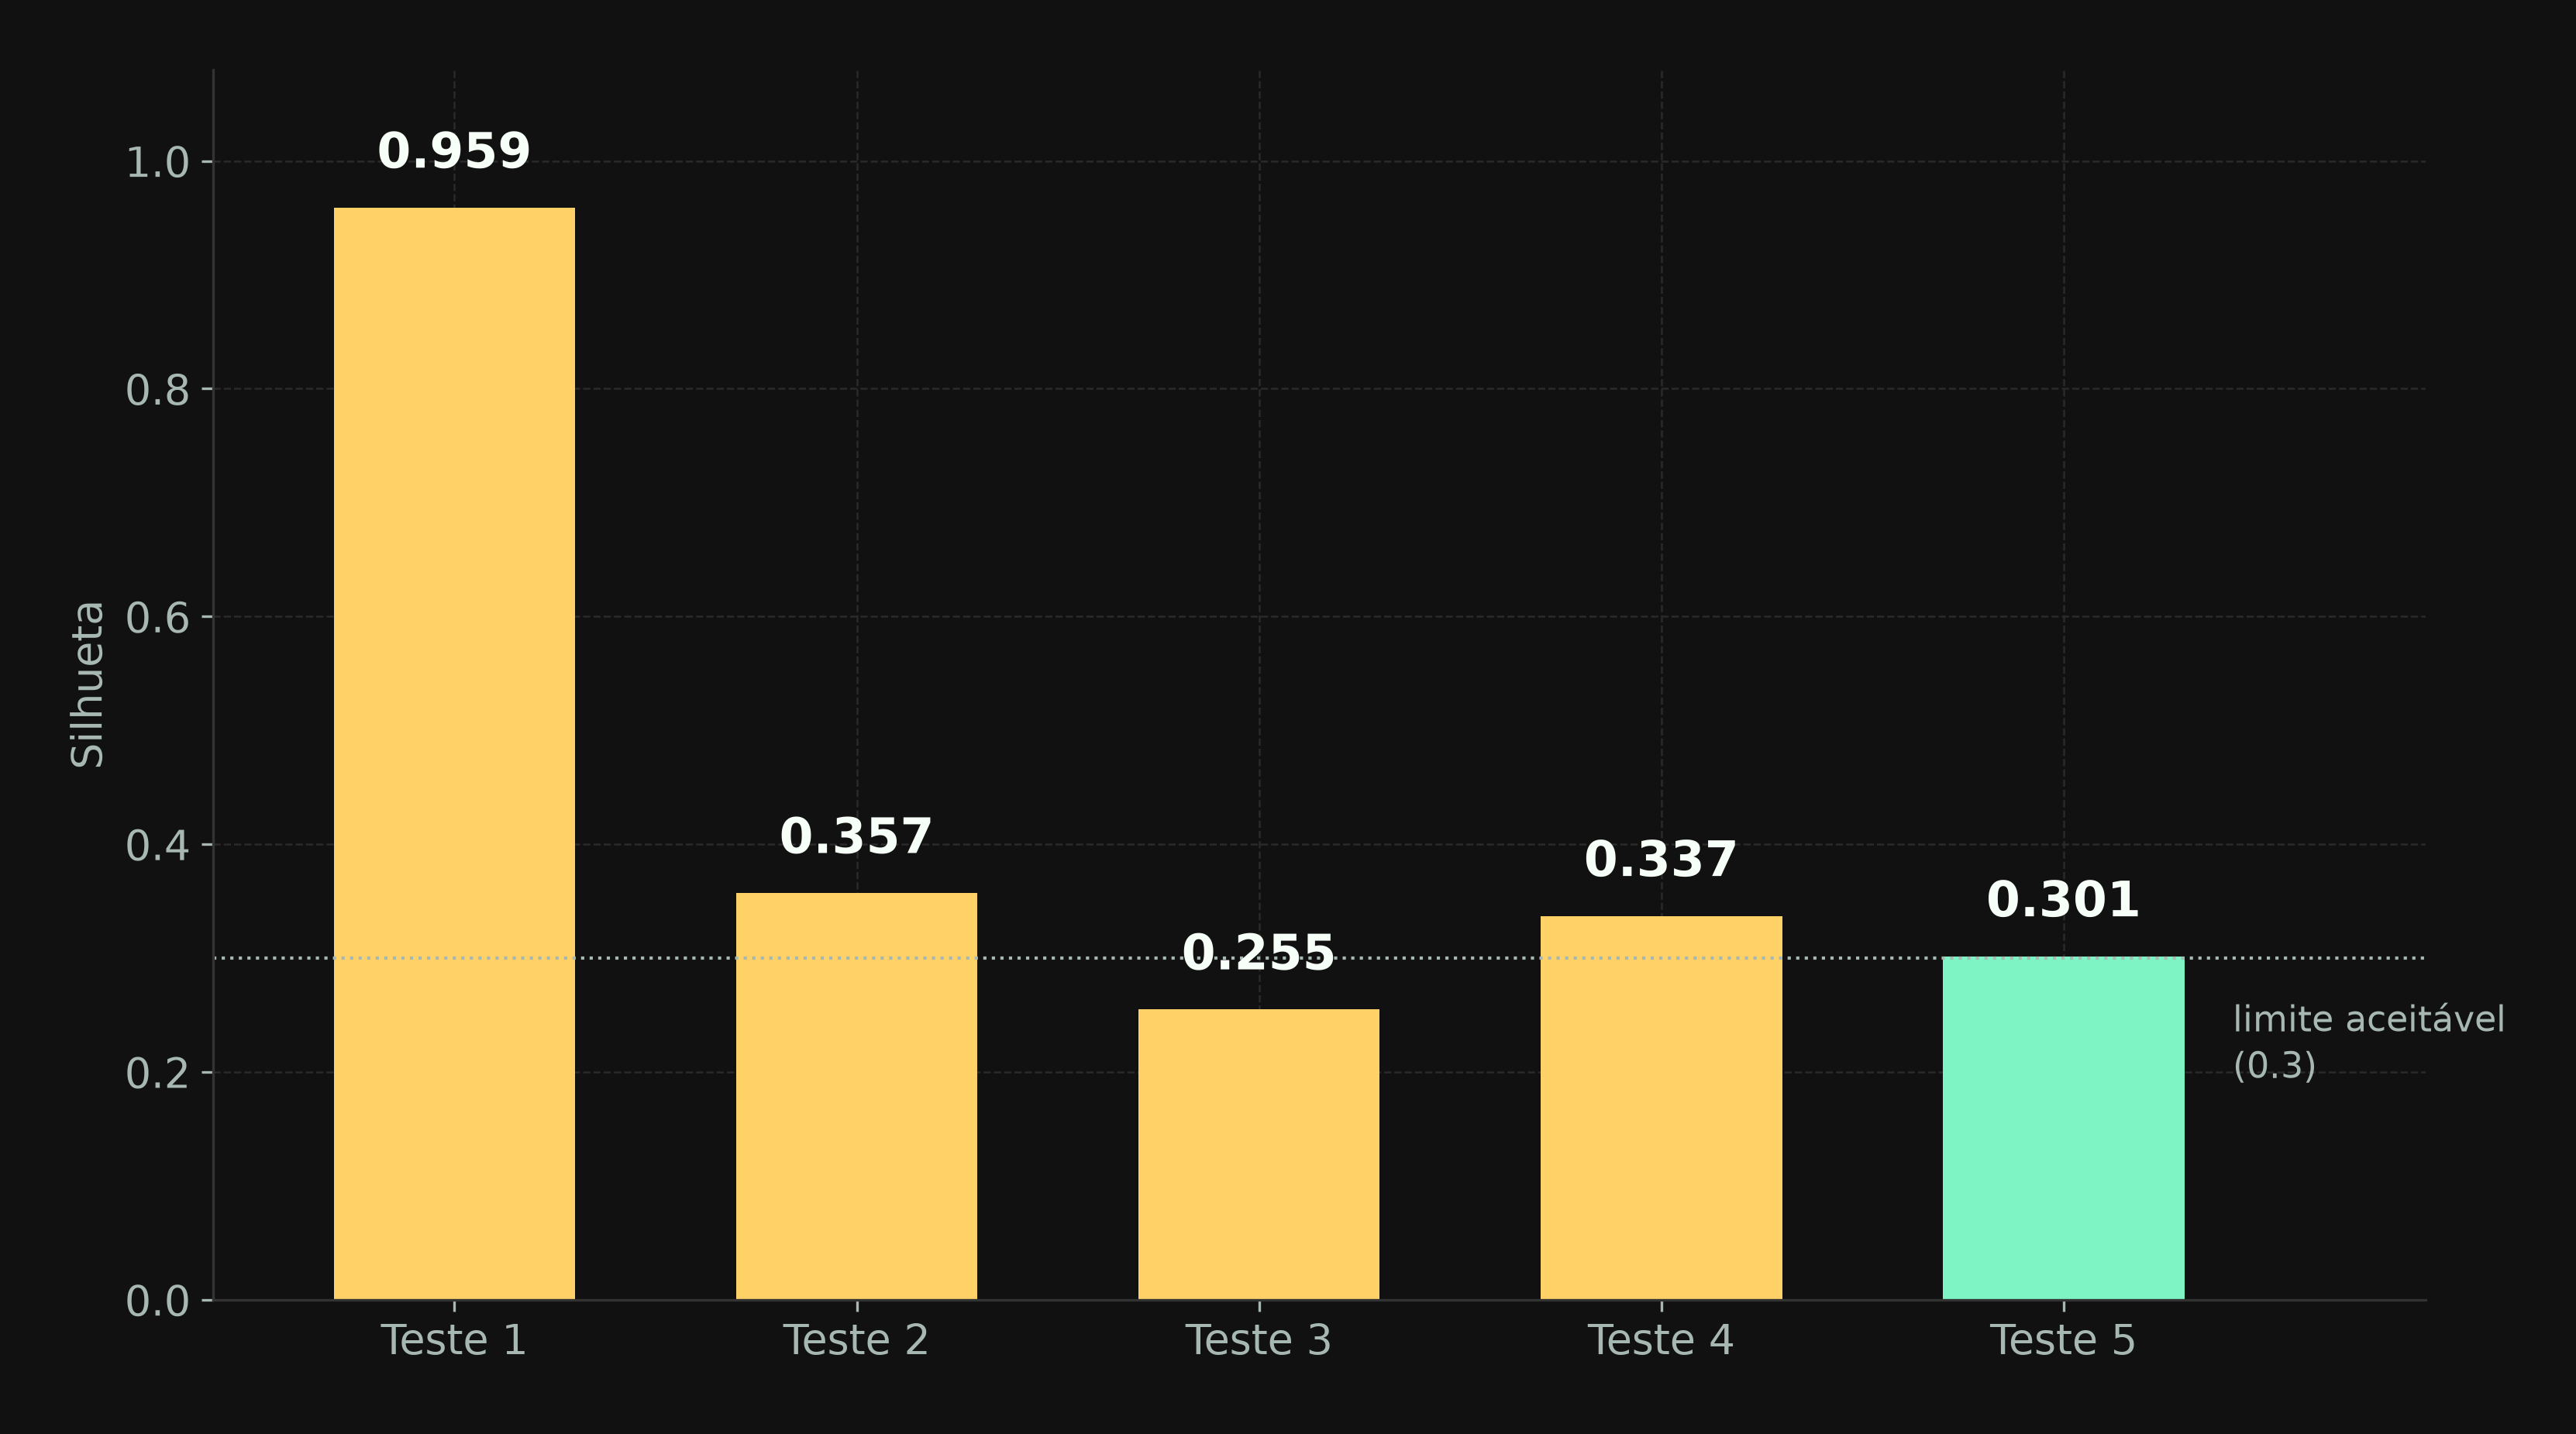

In [6]:
plot_cols = ['teste', 'k', 'n_features', 'silhueta', 'davies_bouldin', 'maior_cluster_%', 'menor_cluster_%']
display(comparativo[plot_cols])
Image(filename=FIGS / 'fig1_jornada_testes.png', width=950)

O gráfico acima mostra o padrão esperado: a silhueta cai conforme o k aumenta (mais grupos =
fronteiras menos óbvias) — isso **não é um defeito**, é o preço de uma segmentação mais granular e
mais útil comercialmente. O Teste 5 foi o escolhido: última configuração acima do limite de 0,3, com
a maior granularidade (5 clusters) entre as opções aceitáveis.

## 5. Resultado final — Teste 5 (k=5, 6 features)

### Como cada feature foi calculada, e por que foi escolhida

Antes de fechar nas 6 features finais, o EDA (`1.EDA_Kmeans.ipynb`, seção 9) testou 13 métricas candidatas
por cliente e mediu a correlação de Spearman entre todas elas — o objetivo é não dar peso duplicado a
métricas que, na prática, medem a mesma coisa (ex: um cliente grande tem volume grande *e* receita
grande *e* lucro grande — são 3 números diferentes contando a mesma história de "porte").

In [7]:
MODEL_CANDIDATES = ['transacoes', 'meses_ativos', 'produtos', 'volume_total', 'receita_liquida_total',
                    'lucro_reposicao_total', 'preco_liquido_ponderado', 'margem_pct_ponderada',
                    'frequencia_mensal', 'cv_volume', 'taxa_devolucao', 'taxa_ajuste', 'taxa_inconsistencia']
corr = customer_features_full[MODEL_CANDIDATES].corr(method='spearman')

redundantes = []
for i, a in enumerate(corr.columns):
    for b in corr.columns[i + 1:]:
        if abs(corr.loc[a, b]) >= 0.90:
            redundantes.append({'variável A': a, 'variável B': b, 'correlação (Spearman)': round(corr.loc[a, b], 3)})
display(pd.DataFrame(redundantes).sort_values('correlação (Spearman)', key=abs, ascending=False))

,variável A,variável B,correlação (Spearman)
2,volume_total,receita_liquida_total,0.993
4,receita_liquida_total,lucro_reposicao_total,0.962
3,volume_total,lucro_reposicao_total,0.955
0,transacoes,meses_ativos,0.939
1,transacoes,produtos,0.901


Pares com correlação ≥ 0,90 (acima) são candidatos a "a mesma informação contada duas vezes":
`volume_total` ↔ `receita_liquida_total` ↔ `lucro_reposicao_total` formam um grupo só de porte;
`transacoes` ↔ `meses_ativos` ↔ `produtos` formam outro. A seleção final manteve **1 representante de
cada grupo redundante**, mais as métricas que não tinham par (preço, margem %, devolução):

<table>
<thead><tr><th>Feature</th><th>Dimensão</th><th>Como é calculada</th><th>Por que essa, e não outra</th></tr></thead>
<tbody>
<tr>
<td><code>volume_total</code></td>
<td>Porte</td>
<td>Soma do volume (m³) de todas as vendas elegíveis do cliente no período</td>
<td>Único representante do grupo de porte — <code>receita_liquida_total</code> e
<code>lucro_reposicao_total</code> correlacionam 0,99 e 0,95 com volume; usar as três daria peso
triplicado ao tamanho do cliente</td>
</tr>
<tr>
<td><code>preco_liquido_ponderado</code></td>
<td>Preço médio ponderado por volume</td>
<td><code>receita_liquida_total ÷ volume_total</code> — sempre soma/soma, nunca média de preços por
transação</td>
<td>Não tinha par redundante; mede quanto custa, em média, <b>um m³</b> (1.000 litros)
comprado pelo cliente, misturando todos os produtos que ele compra. <b>Não é "ticket médio"</b> —
ticket médio seria receita ÷ nº de transações (quanto vale uma compra); aqui o denominador é volume,
não transações. Por ser ponderada pelo mix de produtos do cliente, o produto que ele compra em maior
volume domina o número — ele pode pagar caro por um item de nicho que compra pouco sem que isso
apareça nessa média</td>
</tr>
<tr>
<td><code>margem_pct_ponderada</code></td>
<td>Margem</td>
<td><code>lucro_reposicao_total ÷ receita_liquida_total</code> — lucro de reposição como
<b>percentual</b> da receita, não valor absoluto</td>
<td><b>Preço não é lucro:</b> um cliente pode pagar preço alto e ainda ter margem % baixa (mix caro
de comprar), ou pagar pouco e ter margem % boa. A base tem uma coluna de lucro absoluto real
(<code>LB Reposição</code>, agregada em <code>lucro_reposicao_total</code>), mas ela correlaciona
0,955 com volume — é "porte disfarçado". A versão percentual isola a eficiência de lucratividade,
comparável entre cliente grande e pequeno</td>
</tr>
<tr>
<td><code>frequencia_mensal</code></td>
<td>Frequência</td>
<td><code>transacoes ÷ meses_ativos</code></td>
<td>Único representante do grupo transações/atividade — <code>transacoes</code> correlaciona 0,94 com
<code>meses_ativos</code> e 0,90 com <code>produtos</code>; a razão normaliza por tempo de
relacionamento, ficando comparável entre cliente novo e antigo</td>
</tr>
<tr>
<td><code>taxa_devolucao</code></td>
<td>Comportamento</td>
<td><code>devolucoes ÷ registros_totais</code> — proporção de movimentos classificados como
devolução provável sobre o total de registros do cliente</td>
<td>Não tinha par redundante; nenhuma outra feature capturava risco/qualidade de relacionamento</td>
</tr>
<tr>
<td><code>produtos</code></td>
<td>Diversidade</td>
<td>Nº de <code>Código Material</code> distintos comprados pelo cliente (contagem de valores únicos)</td>
<td>Representa o grupo transações/atividade (junto com <code>frequencia_mensal</code>); citada na
conclusão do EDA como dimensão a equilibrar, mas ficou de fora da seleção inicial de 5 — adicionada
nos Testes 4 e 5 (seção 4) e validada por melhorar a segmentação</td>
</tr>
</tbody>
</table>

A unidade de `Volume` (m³) foi confirmada cruzando `Receita líquida ÷ 'Receita Liquida por m³'`
contra a coluna `Volume` bruta — bate em 94% das linhas dentro de ±5% (ver `1.EDA_Kmeans.ipynb`, seção 5,
"Conclusão da etapa").

Isso também bate com a ordem de grandeza: se o preço mediano (~R\$ 12.772) fosse por litro, seria
um valor absurdo para lubrificante (ninguém paga R\$ 12 mil por litro); por m³ (= 1.000 litros), vira
~R\$ 12,77/litro — perfeitamente plausível para venda B2B de lubrificante a granel.

### Perfil dos 5 clusters

In [8]:
seg = pd.read_csv(CLUSTER / 'segmentacao_clientes_kmeans.csv')
NOMES = {0: 'Base Padrão', 1: 'Estratégicos (Grande Volume)', 2: 'Volume Médio Diversificado',
         3: 'Nicho Premium (Alto Valor Unit.)', 4: 'Volume Médio Padrão'}
FEATURES = ['volume_total', 'preco_liquido_ponderado', 'margem_pct_ponderada', 'frequencia_mensal', 'produtos']
perfil = seg.groupby('cluster')[FEATURES].mean().round(2)
perfil.insert(0, 'nome_sugerido', perfil.index.map(NOMES))
perfil.insert(1, 'n_clientes', seg['cluster'].value_counts().sort_index())
perfil.insert(2, 'pct', (seg['cluster'].value_counts(normalize=True).sort_index() * 100).round(1))
display(perfil)

,nome_sugerido,n_clientes,pct,volume_total,preco_liquido_ponderado,margem_pct_ponderada,frequencia_mensal,produtos
cluster,,,,,,,,
0,Base Padrão,4071,56.7,2.91,12149.30,0.17,1.64,3.84
1,Estratégicos (Grande Volume),129,1.8,111.49,12470.89,0.15,5.01,19.46
2,Volume Médio Diversificado,525,7.3,45.77,12730.83,0.16,3.74,17.47
3,Nicho Premium (Alto Valor Unit.),883,12.3,2.57,18759.52,0.14,1.89,4.45
4,Volume Médio Padrão,1568,21.9,12.87,13126.59,0.16,3.71,14.48


> Os nomes na coluna `nome_sugerido` são propostas para facilitar a leitura — não são uma decisão
> de negócio validada. Precisam de checagem com o time comercial antes de virar rótulo oficial.

### O que cada cluster representa

- **Base Padrão** (4.071 clientes, 56,7%) — o grosso da carteira. Volume baixo (2,9 m³ em média),
  compra poucos produtos diferentes (3,8) e raramente (1,6 vez/mês). Preço e margem dentro da média
  geral. É o perfil "cliente comum": baixo engajamento, sem nenhum traço que se destaque.

- **Estratégicos (Grande Volume)** (129 clientes, 1,8%) — o menor grupo, mas o mais valioso em
  volume: compram **111,5 m³** em média (quase 40× o volume da Base Padrão), de **19,5** produtos
  diferentes, com frequência alta (5,0 vezes/mês). Preço em linha com a média geral — não é
  "premium" no preço, é grande e engajado. Candidato natural a atendimento dedicado.

- **Volume Médio Diversificado** (525 clientes, 7,3%) — o mesmo perfil dos Estratégicos, em escala
  menor: volume médio-alto (45,8 m³), muitos produtos (17,5), frequência boa (3,7). Uma espécie de
  "estratégico em formação" — candidato a acompanhamento próximo para crescer de segmento.

- **Nicho Premium (Alto Valor Unitário)** (883 clientes, 12,3%) — o único cluster que não se
  diferencia por volume, e sim por **preço**: paga em média **R\$ 18.760 por m³**, bem acima dos
  ~R\$ 12-13 mil/m³ dos demais clusters. Em compensação, compra pouco (2,6 m³), poucos produtos (4,5) e
  raramente (1,9 vez/mês). Vale entender *por que* paga mais (produto específico? urgência? falta
  de alternativa logística?) antes de qualquer ação de preço.

- **Volume Médio Padrão** (1.568 clientes, 21,9%) — perfil intermediário em quase tudo: volume
  (12,9 m³), produtos (14,5) e frequência (3,7) ficam entre a Base Padrão e os clusters de maior
  volume. Não tem um traço tão marcante quanto os outros 4 — é a "classe média" da segmentação.

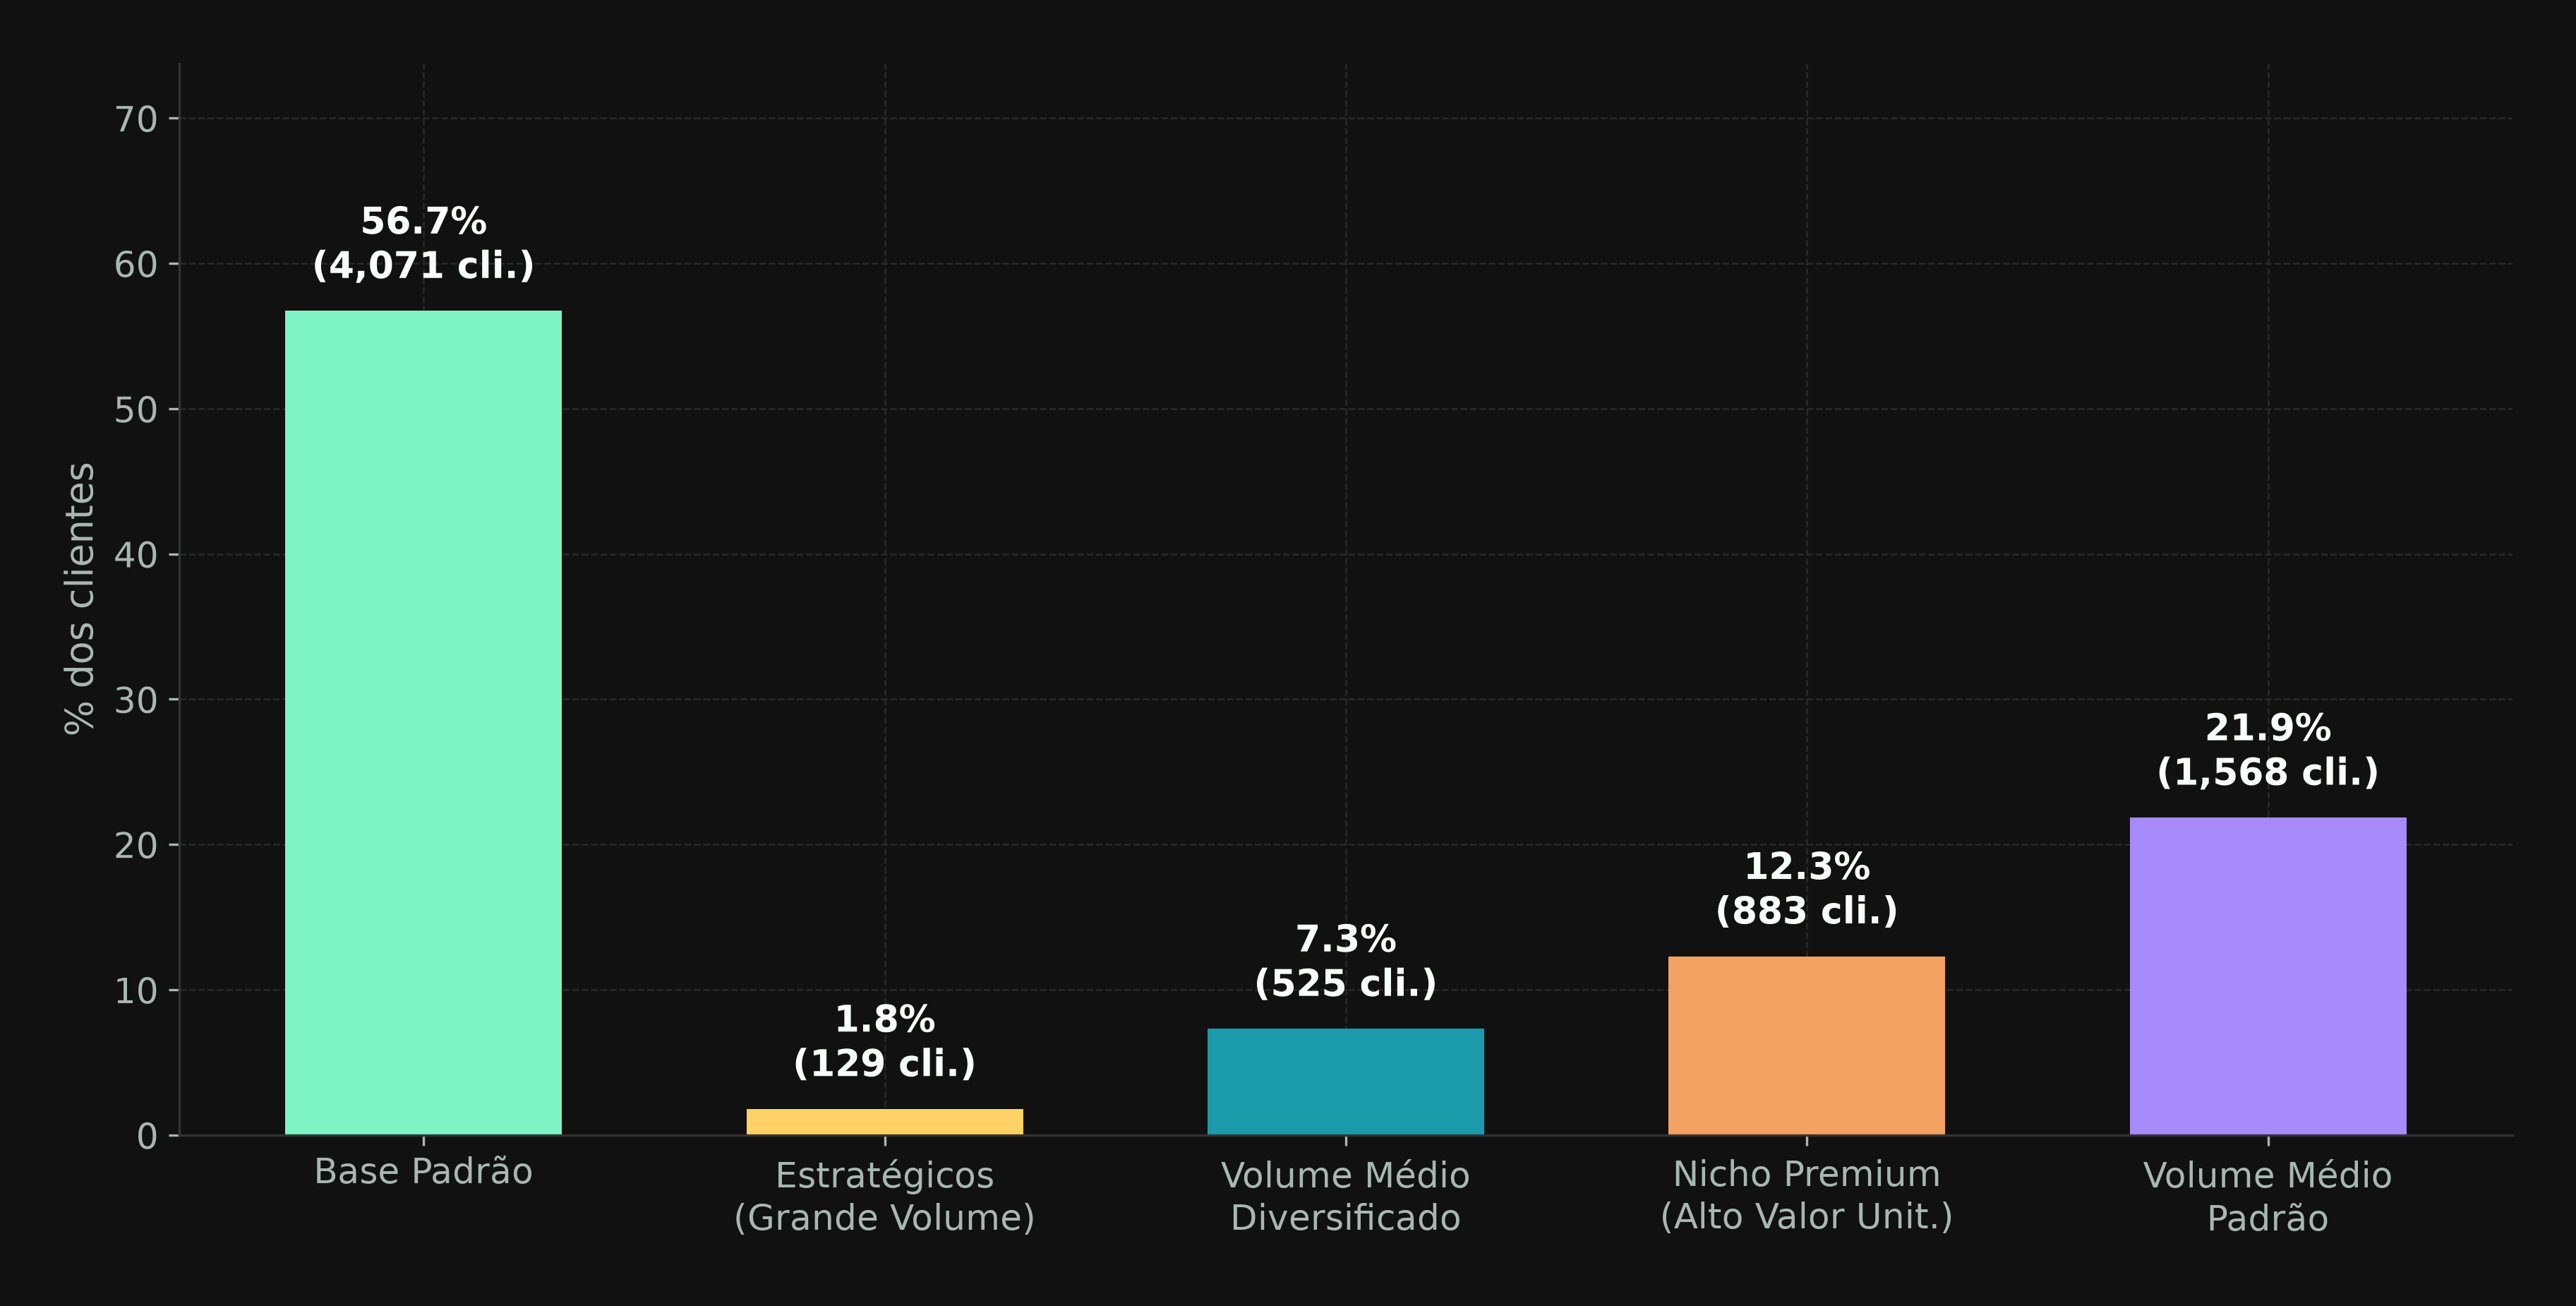

In [9]:
Image(filename=FIGS / 'fig2_distribuicao_clusters.png', width=950)

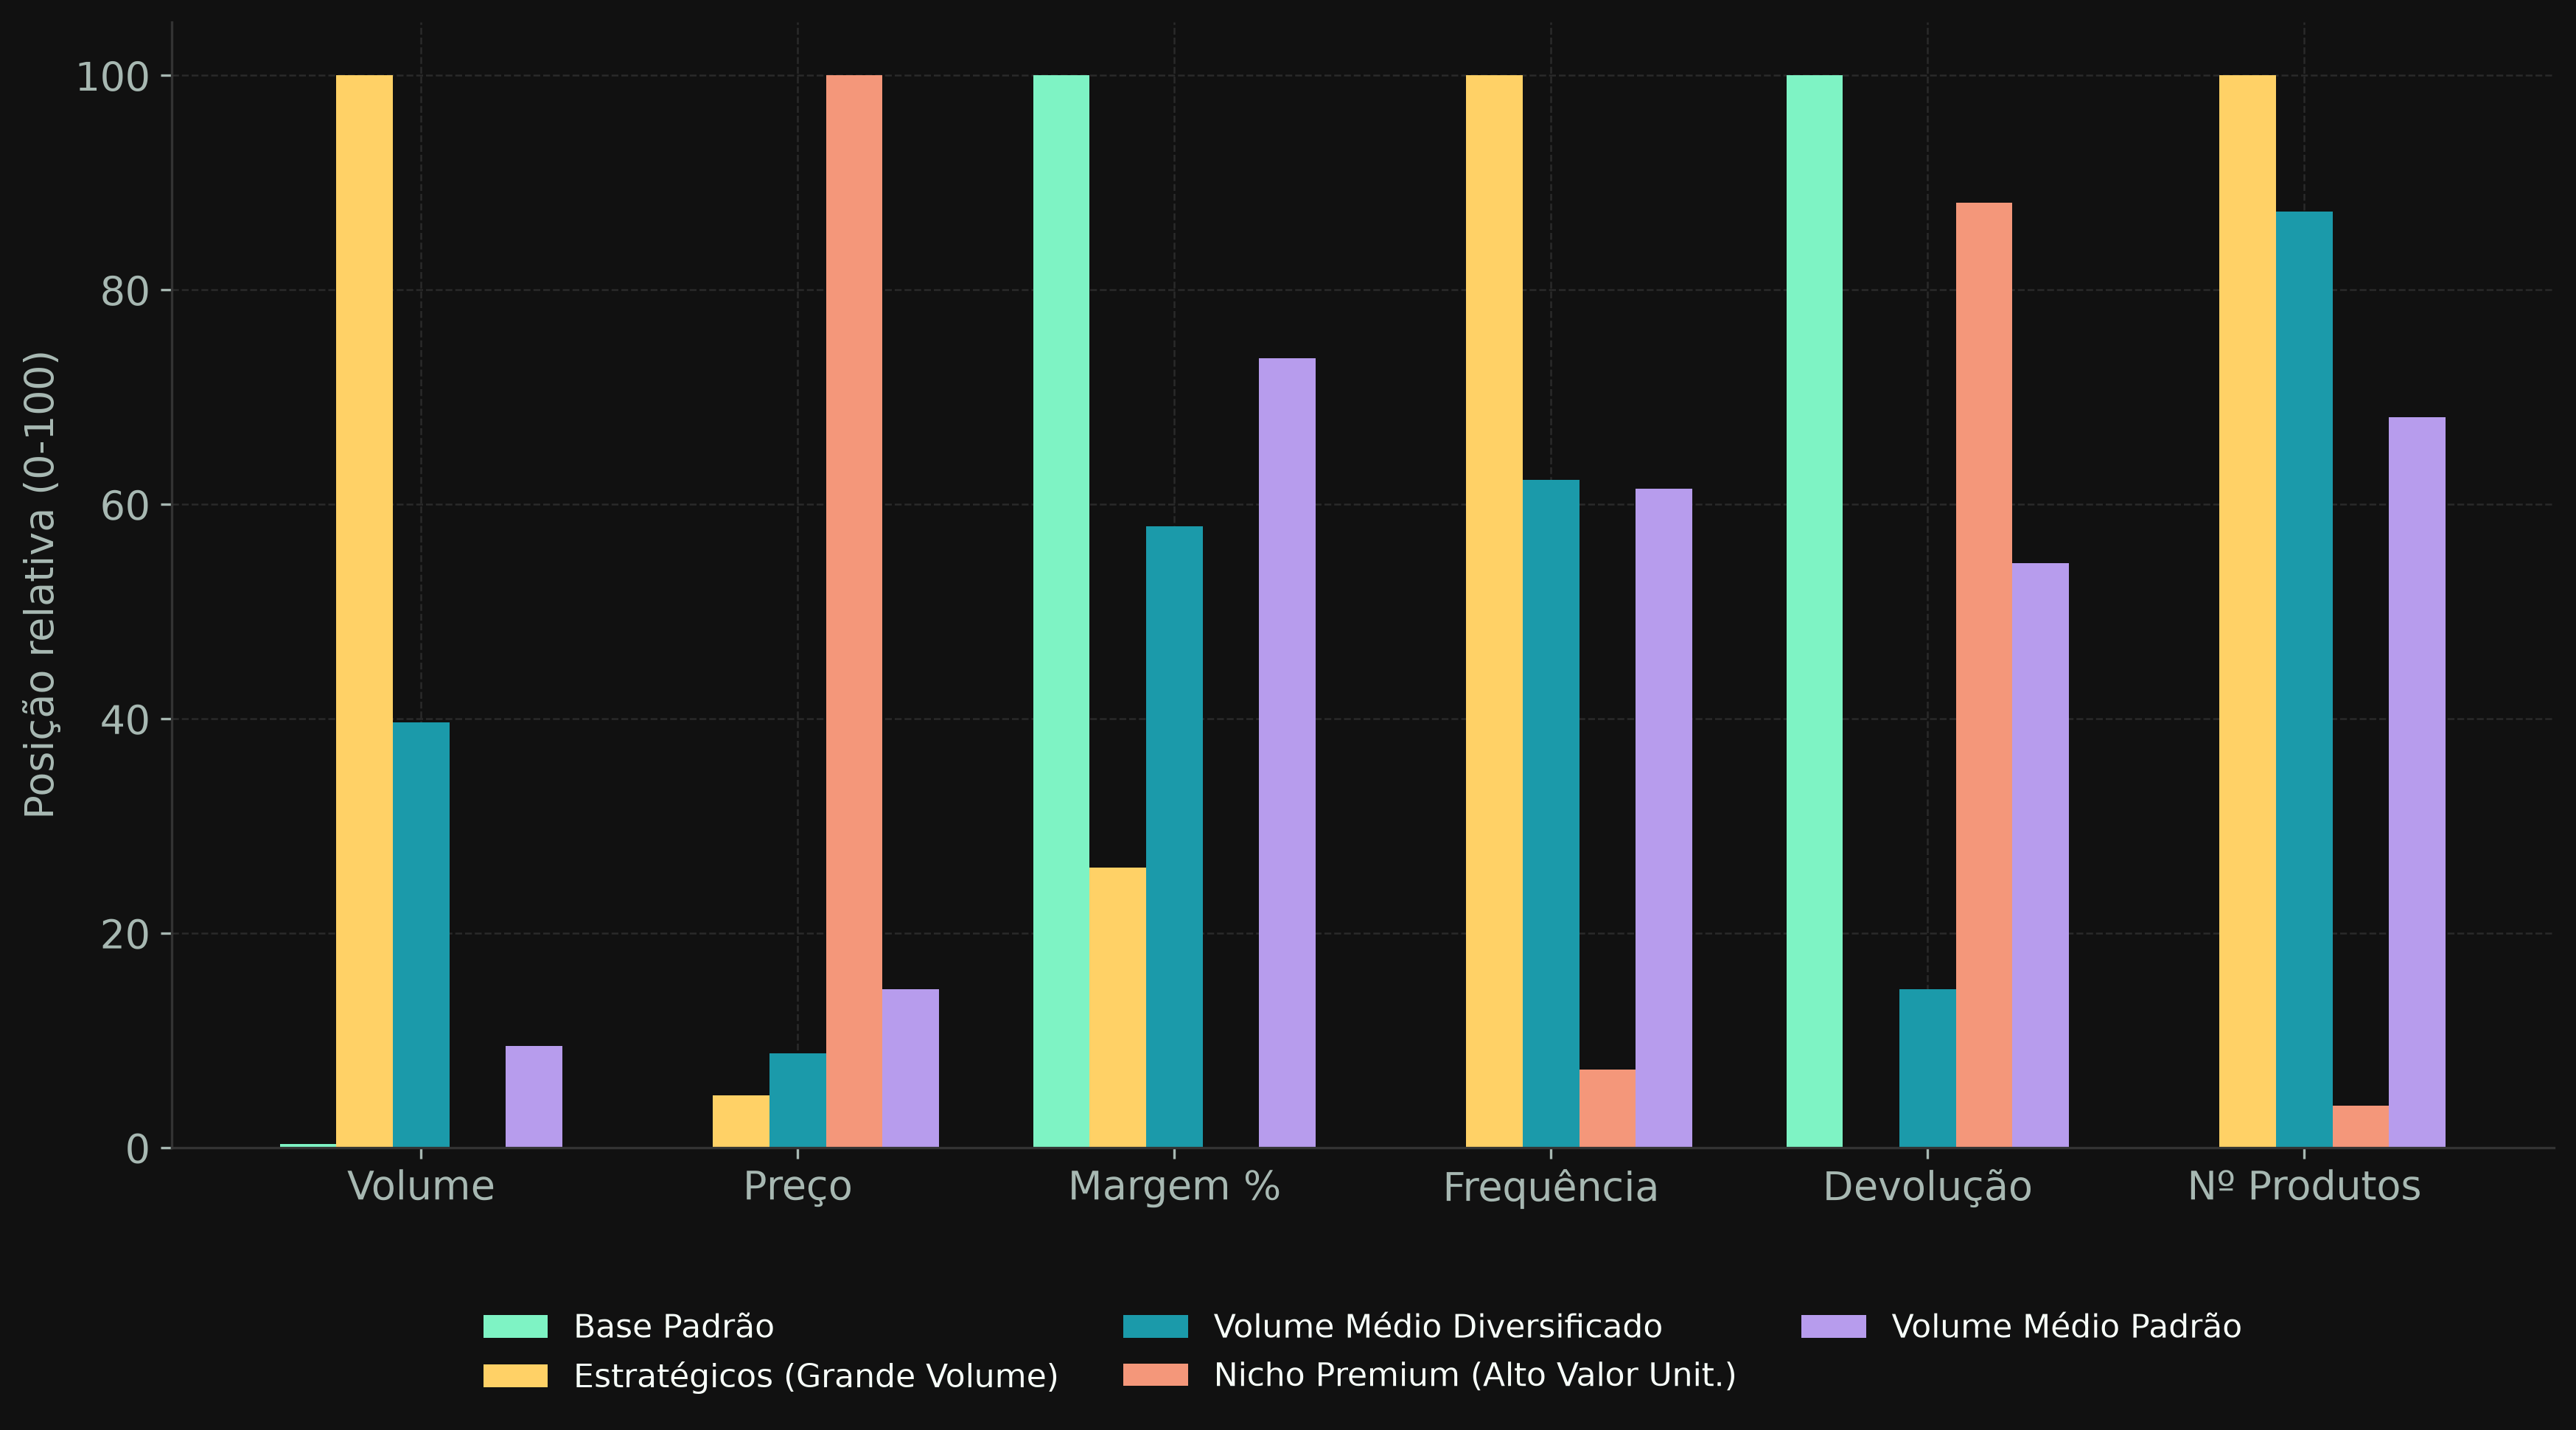

In [10]:
Image(filename=FIGS / 'fig3_perfil_clusters.png', width=950)

A projeção PCA abaixo reduz as 6 dimensões a 2 eixos (que juntos explicam 75,2% da variância) só
para visualização — o modelo em si usa as 6 dimensões originais, não essa projeção.

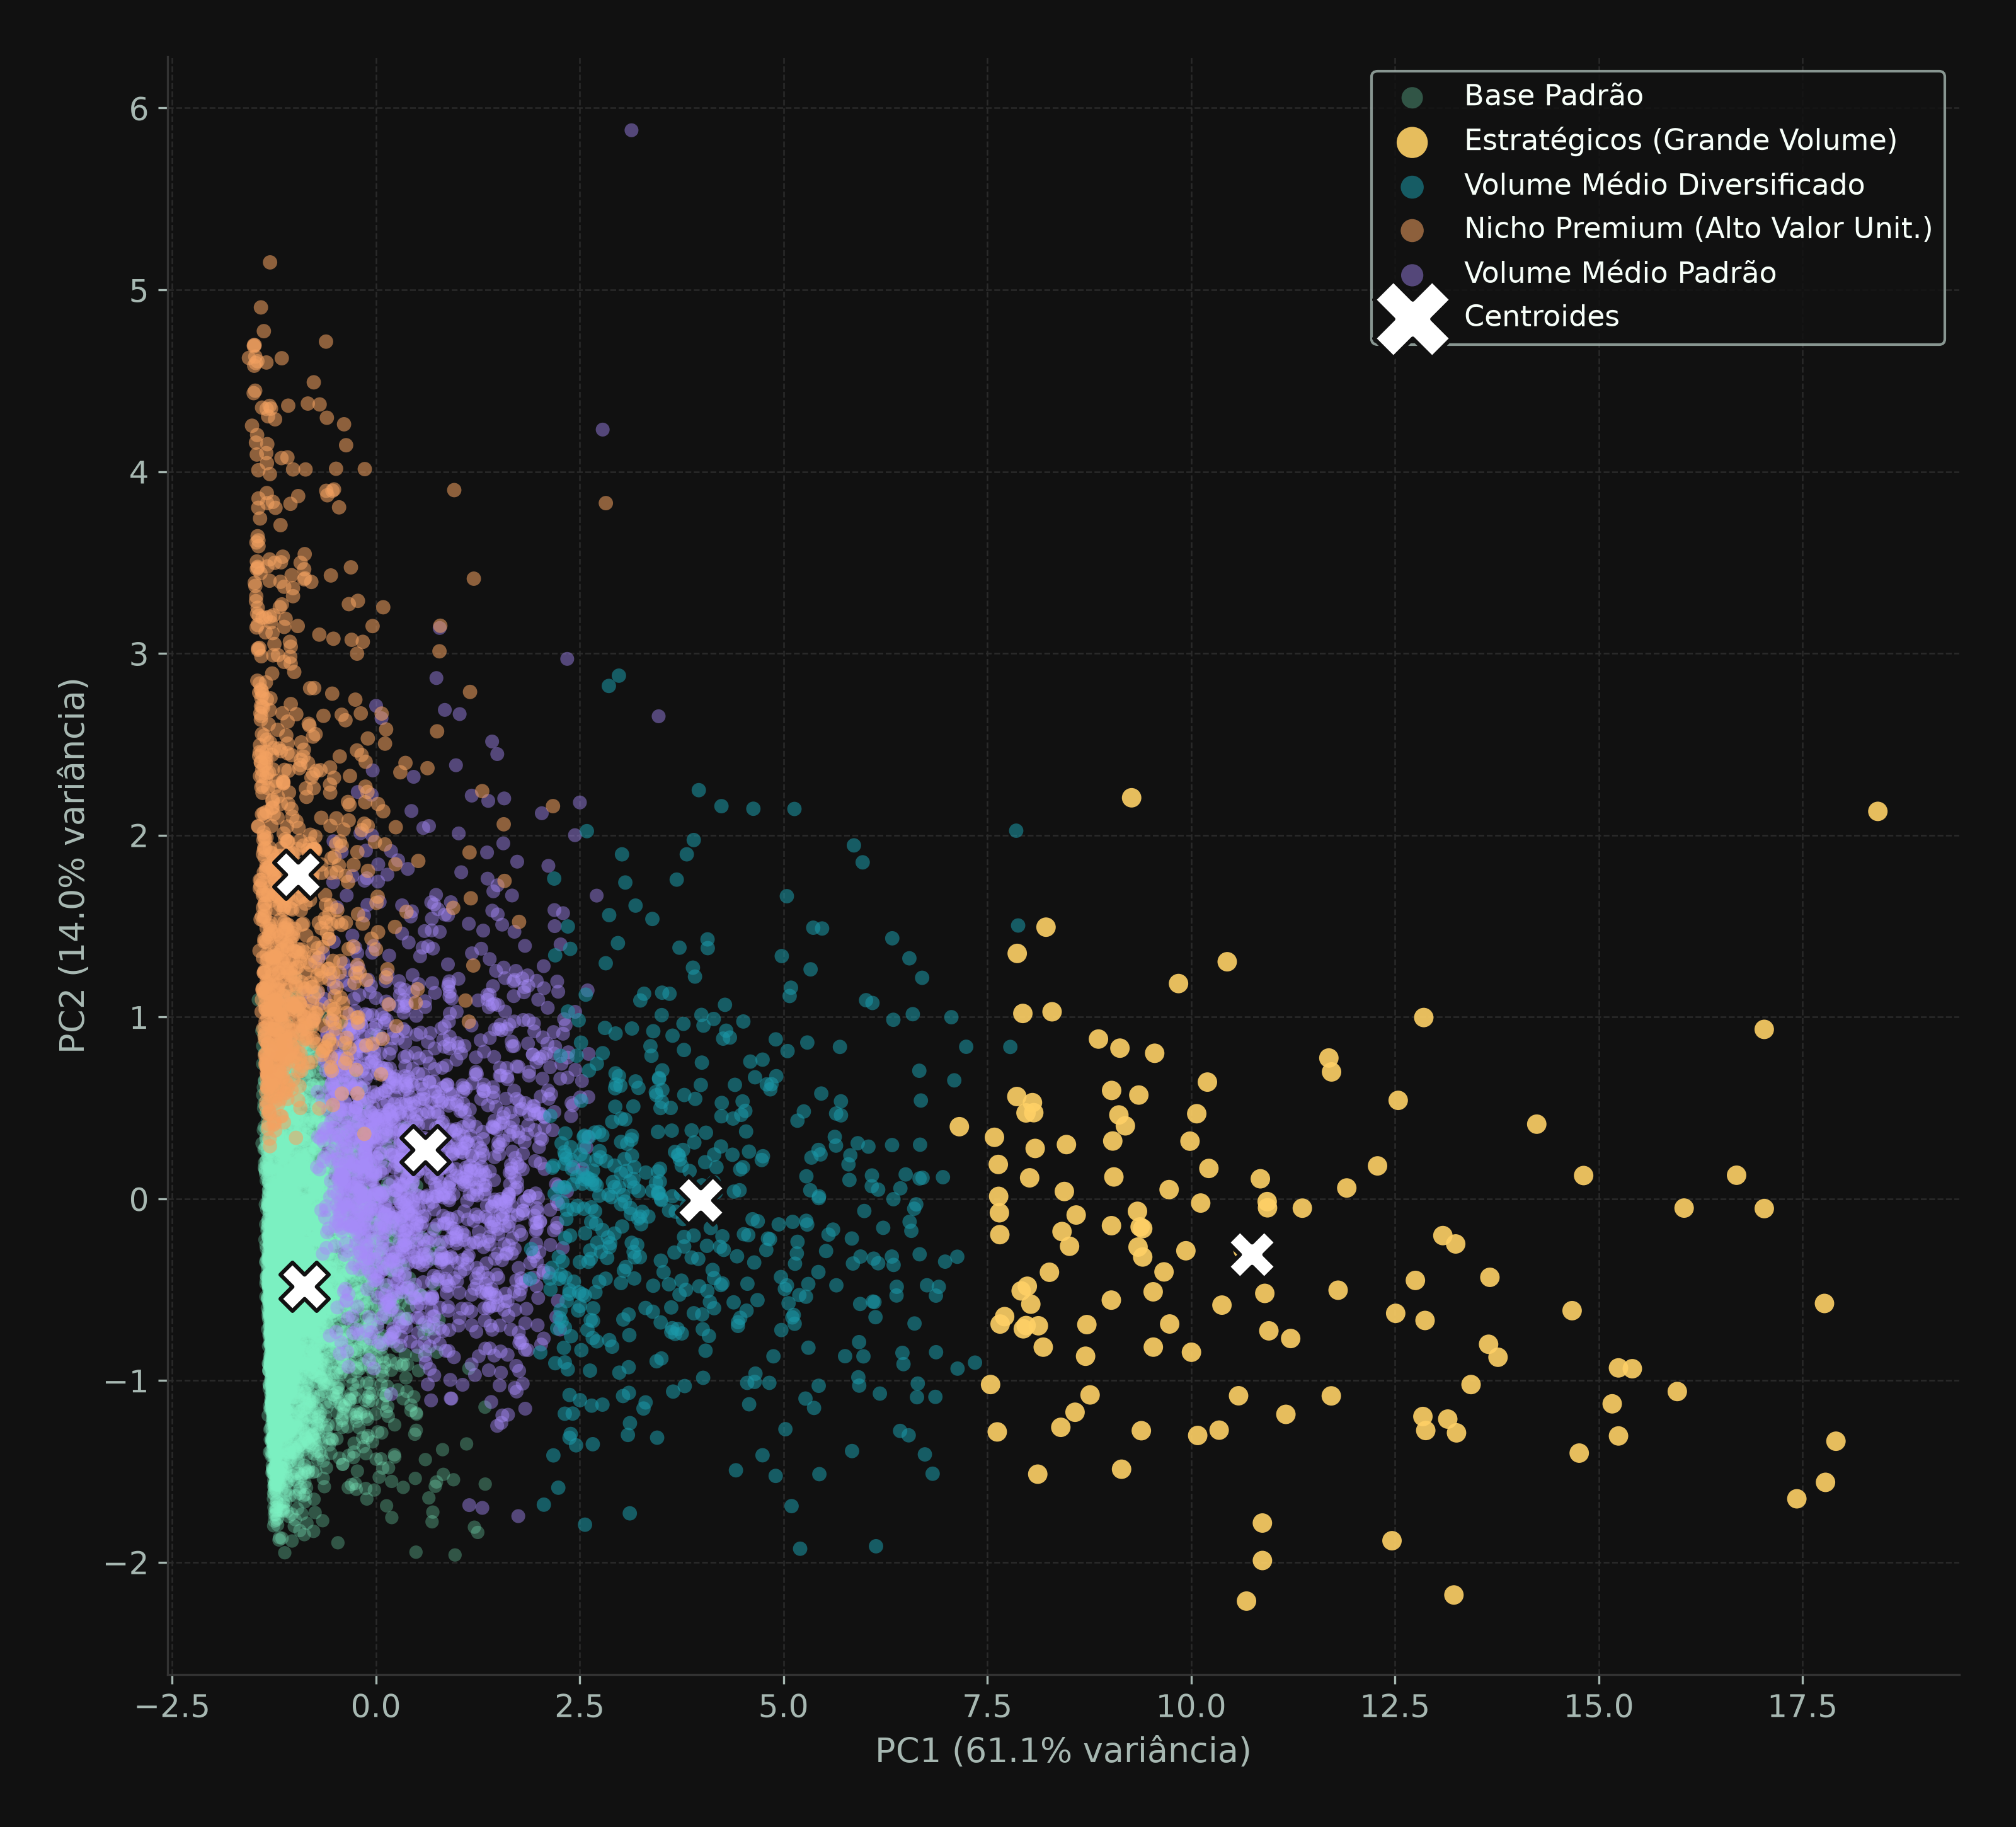

In [11]:
Image(filename=FIGS / 'fig4_pca_clusters.png', width=950)

## 6. Enriquecimento — segmentação híbrida (família × frequência)

Os 5 clusters dizem **quem é parecido com quem**. Para virar uma tabela de preços operacional,
cruzamos cada cluster com duas dimensões que o modelo não captura diretamente:

- **Família de produto:** as 8 famílias de maior volume (72,3% do total) nomeadas individualmente —
  AV, TOP TURBO, HYDRA XP, HYDRA, TOP TURBO PRO, GEAR, GL 5, TRM 5 — e as 102 famílias restantes
  agrupadas em `Outras` (cobertura final: 100%).
- **Frequência de compra:** discretizada em 3 níveis a partir de `frequencia_mensal` — Ocasionais
  (< 1,5/mês), Regulares (1,5–3,5/mês), Frequentes (> 3,5/mês).

Duas decisões de metodologia que o pedido original não detalhava, e que valem registro:

1. **Família por transação vs. família principal do cliente:** a matriz cluster × família usa a
   família de cada *transação* (um cliente que compra de 2 famílias aparece em 2 colunas); já a
   segmentação final por cliente usa a família de **maior volume** do cliente ("família principal") —
   por isso 2 das 45 células da matriz não têm uma frequência dominante correspondente (nenhum
   cliente tem aquela família específica como principal, mesmo comprando um pouco dela).
2. **Consolidação de células pequenas:** em vez de realocar clientes para a "família mais próxima em
   volume" (heurística frágil e difícil de auditar), toda combinação cluster×família com menos de 10
   clientes é fundida em `Outras/Baixo volume` dentro do mesmo cluster — determinístico e simples de
   conferir.

O gráfico abaixo mostra o ranking completo de volume por família, incluindo as 8 nomeadas individualmente e o agregado `Outras`.


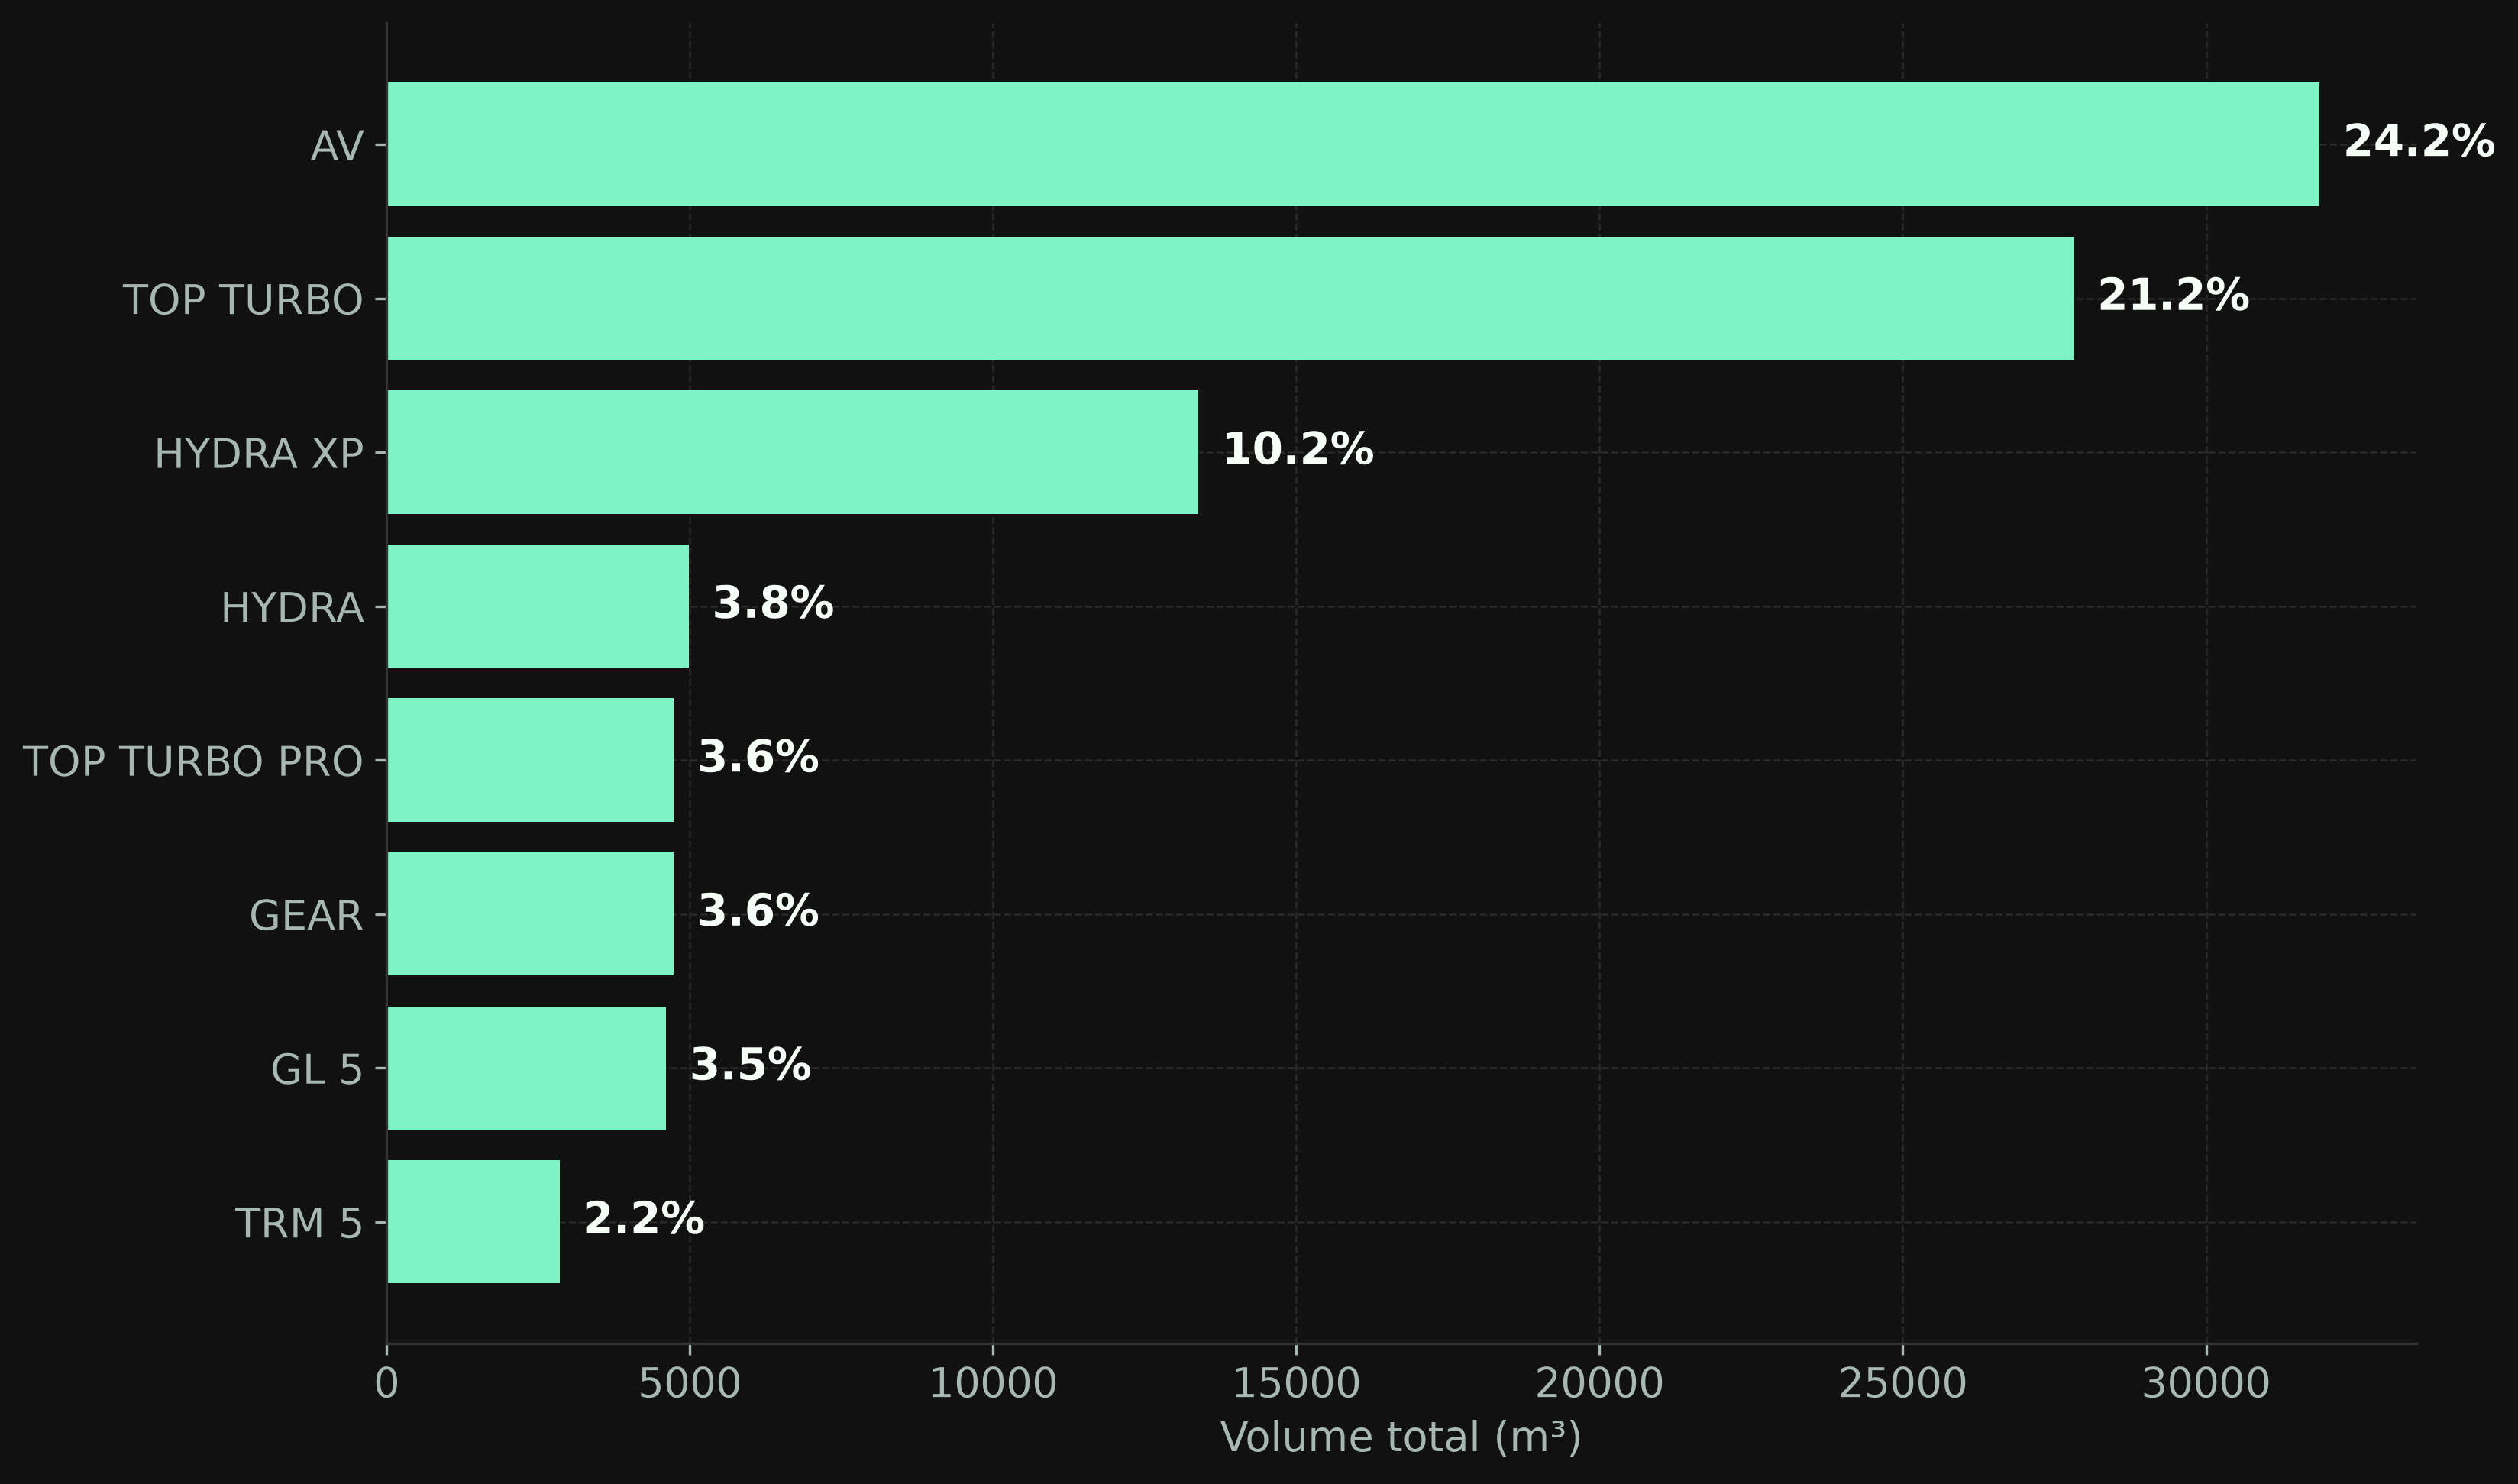

In [12]:
Image(filename=FIGS / 'fig7_top_familias.png', width=950)


Frequência de compra também não se distribui igual entre os clusters — o gráfico abaixo mostra a composição de níveis de frequência (Ocasionais / Regulares / Frequentes) dentro de cada cluster.


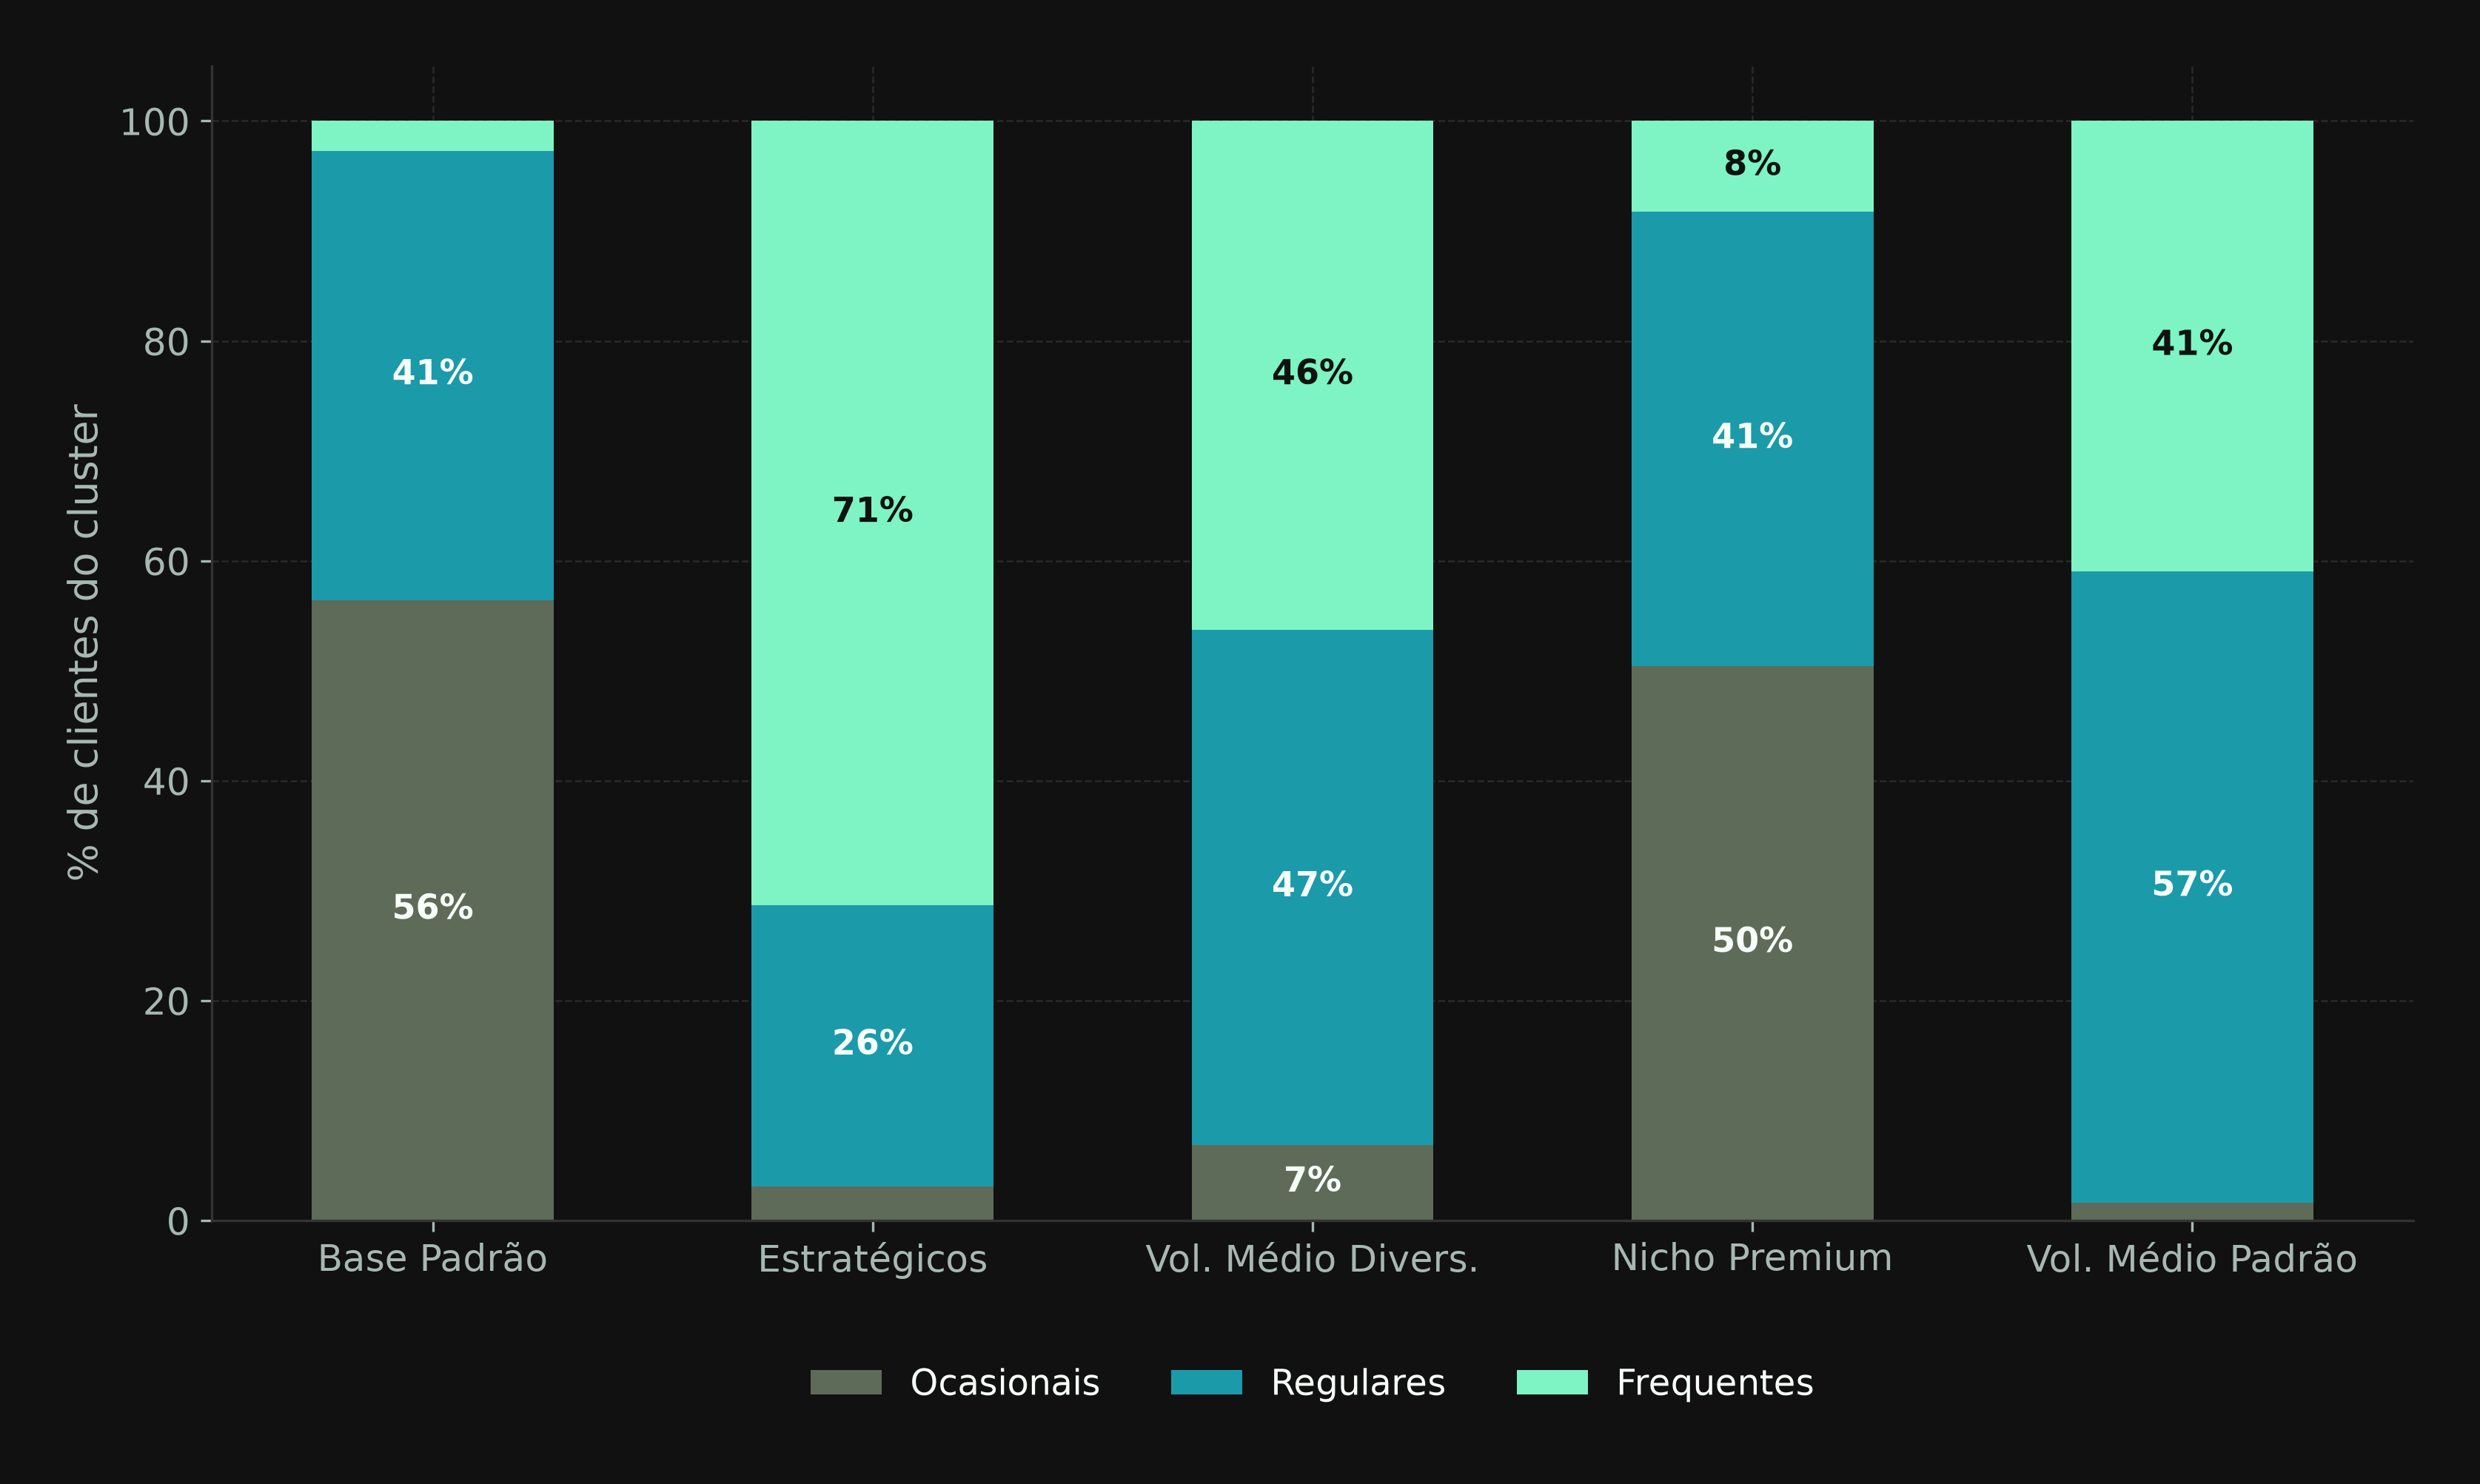

In [13]:
Image(filename=FIGS / 'fig8_frequencia_por_cluster.png', width=950)


Segmentos (cluster × família): 45
Com menos de 10 clientes: 1


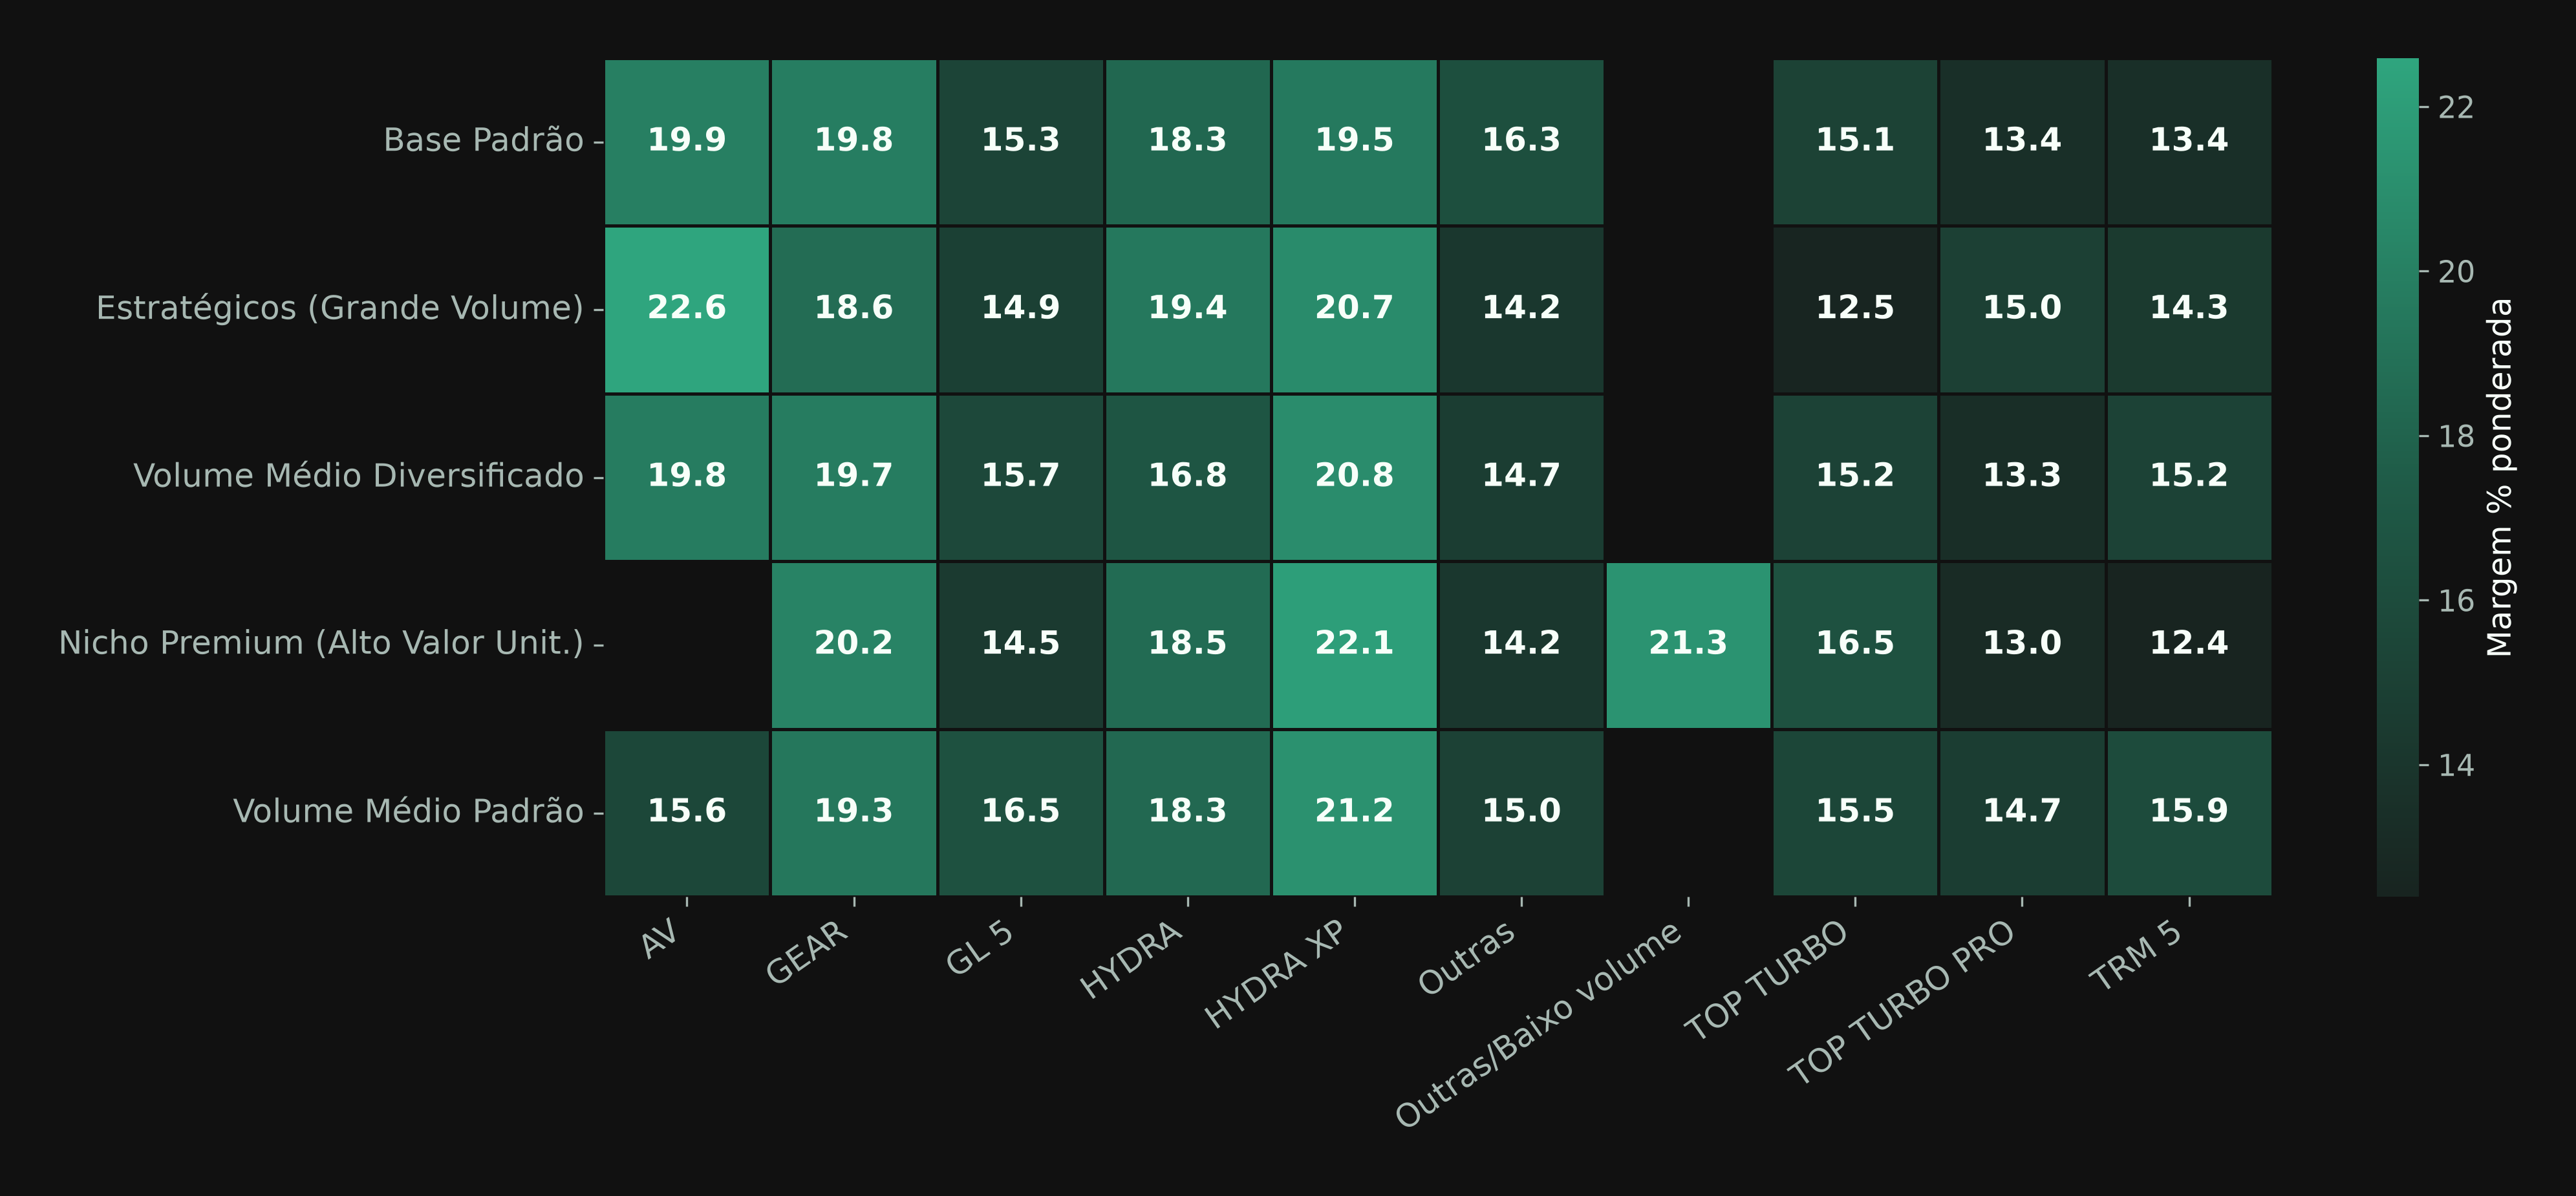

In [14]:
matriz = pd.read_csv(CLUSTER / '2.segmentacao_hibrida' / 'matriz_cluster_familia_consolidada.csv')
print(f"Segmentos (cluster × família): {len(matriz)}")
print(f"Com menos de 10 clientes: {(matriz['clientes_unicos'] < 10).sum()}")
Image(filename=FIGS / 'fig6_heatmap_margem.png', width=950)

O mesmo cruzamento cluster × família, agora pelo preço médio ponderado por volume (em vez de margem) — mostra onde o preço já é mais alto ou mais baixo em cada combinação.


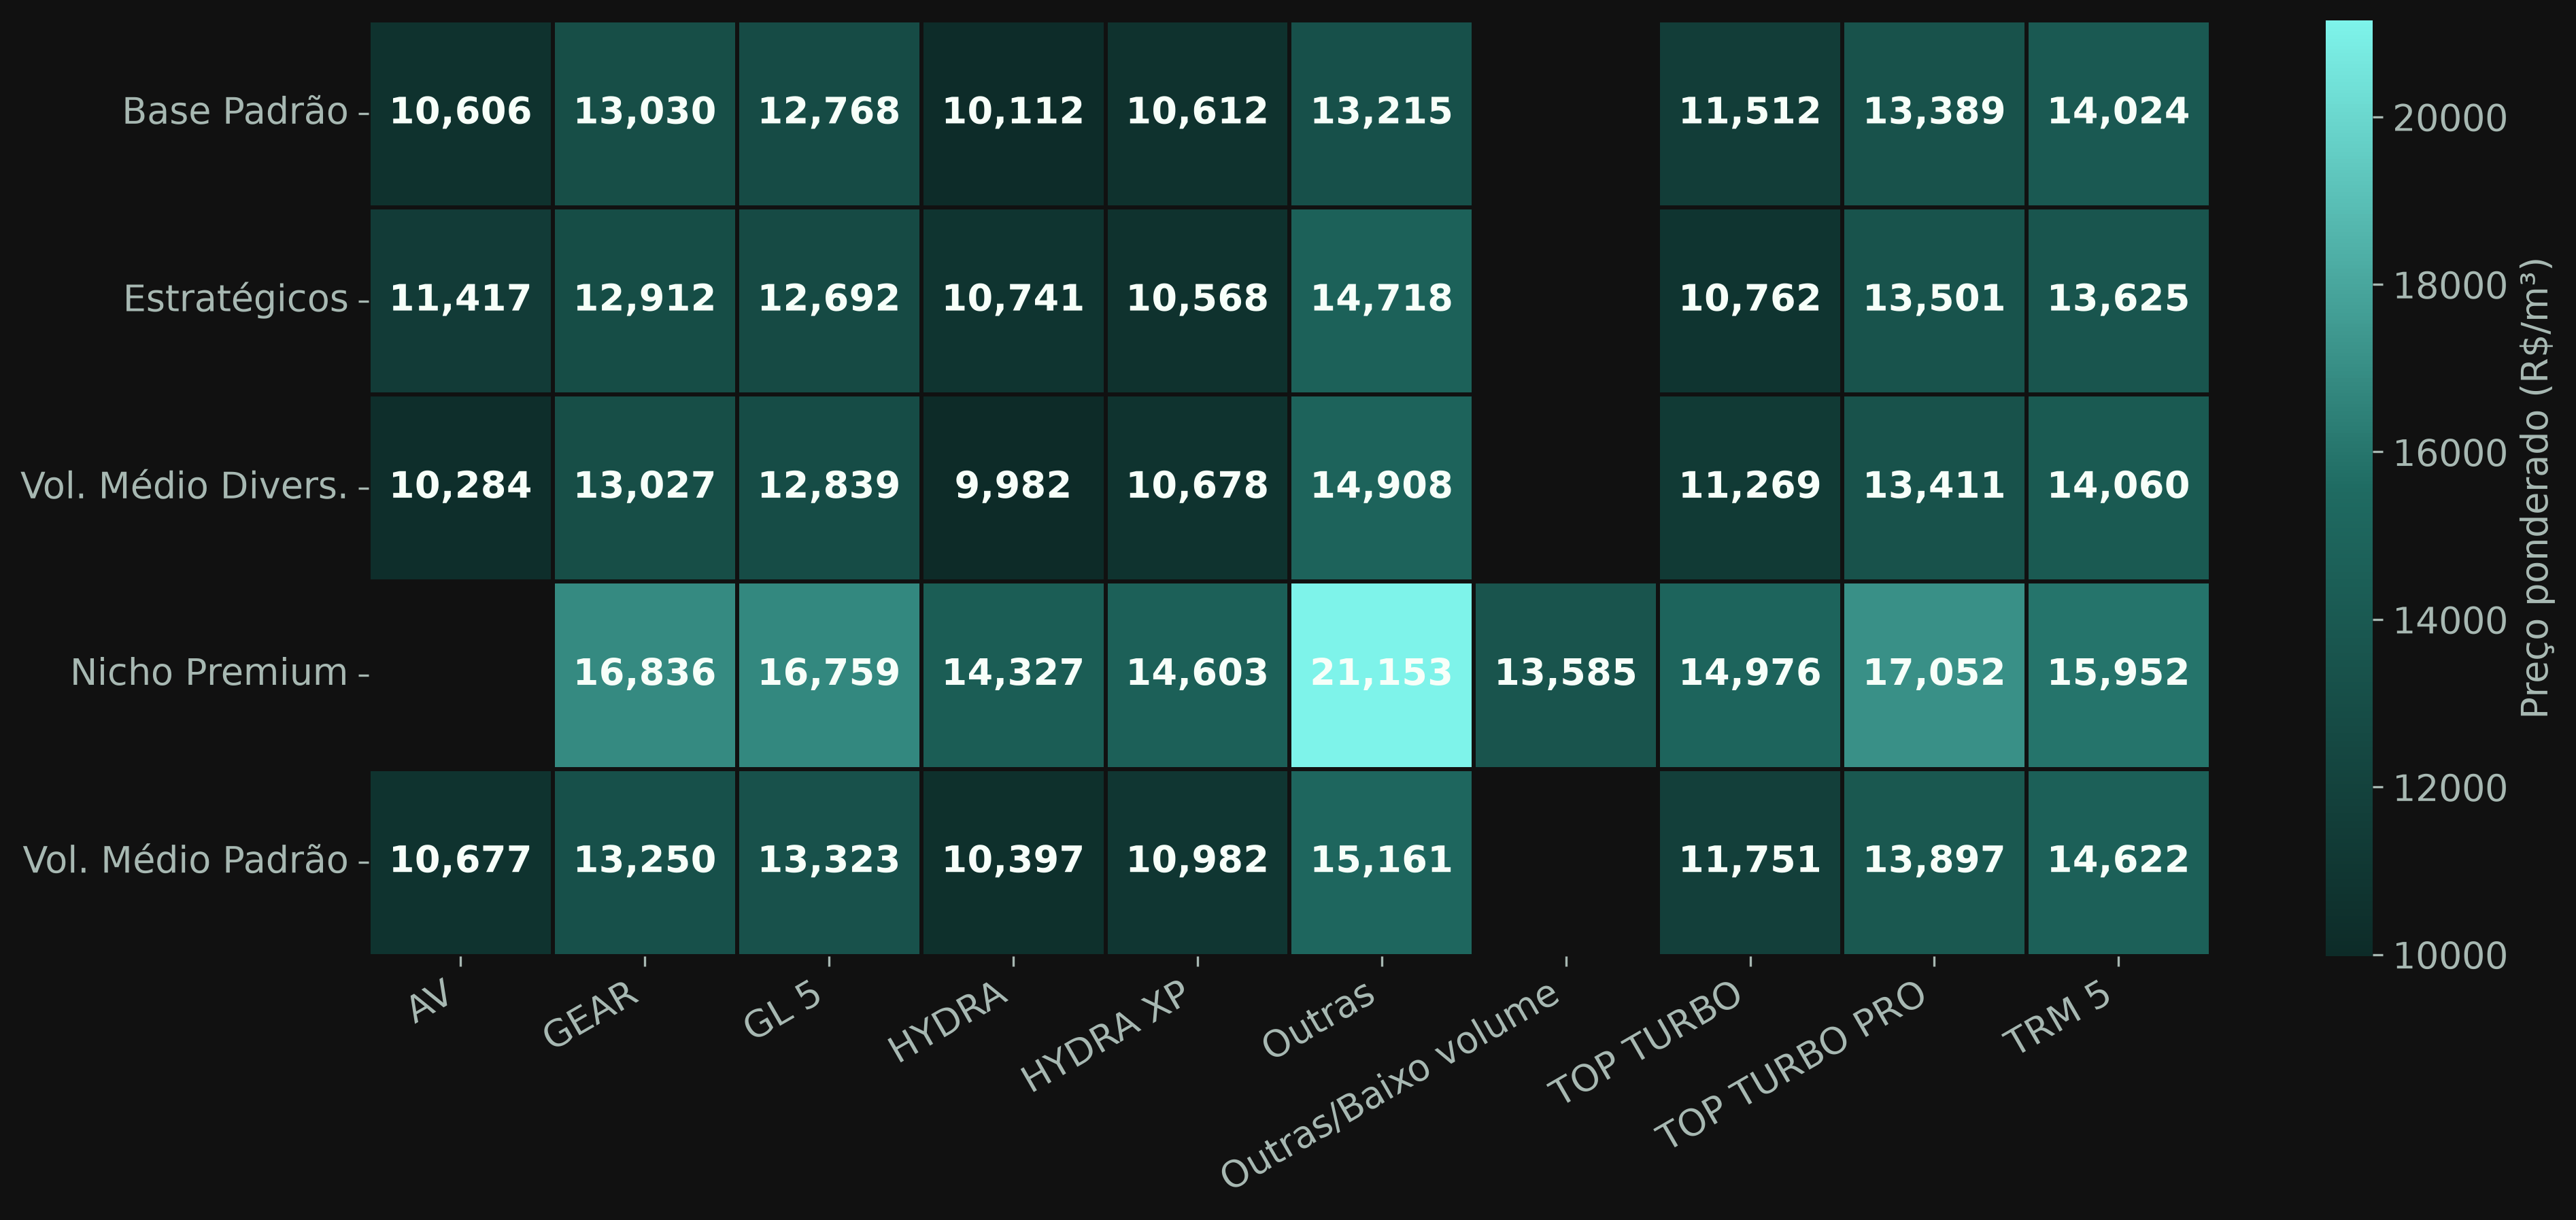

In [15]:
Image(filename=FIGS / 'fig10_heatmap_preco.png', width=950)


### Onde focar primeiro

A receita não se distribui igualmente entre os 45 segmentos — poucos concentram a maior parte.

16 de 45 segmentos cobrem 80% da receita total


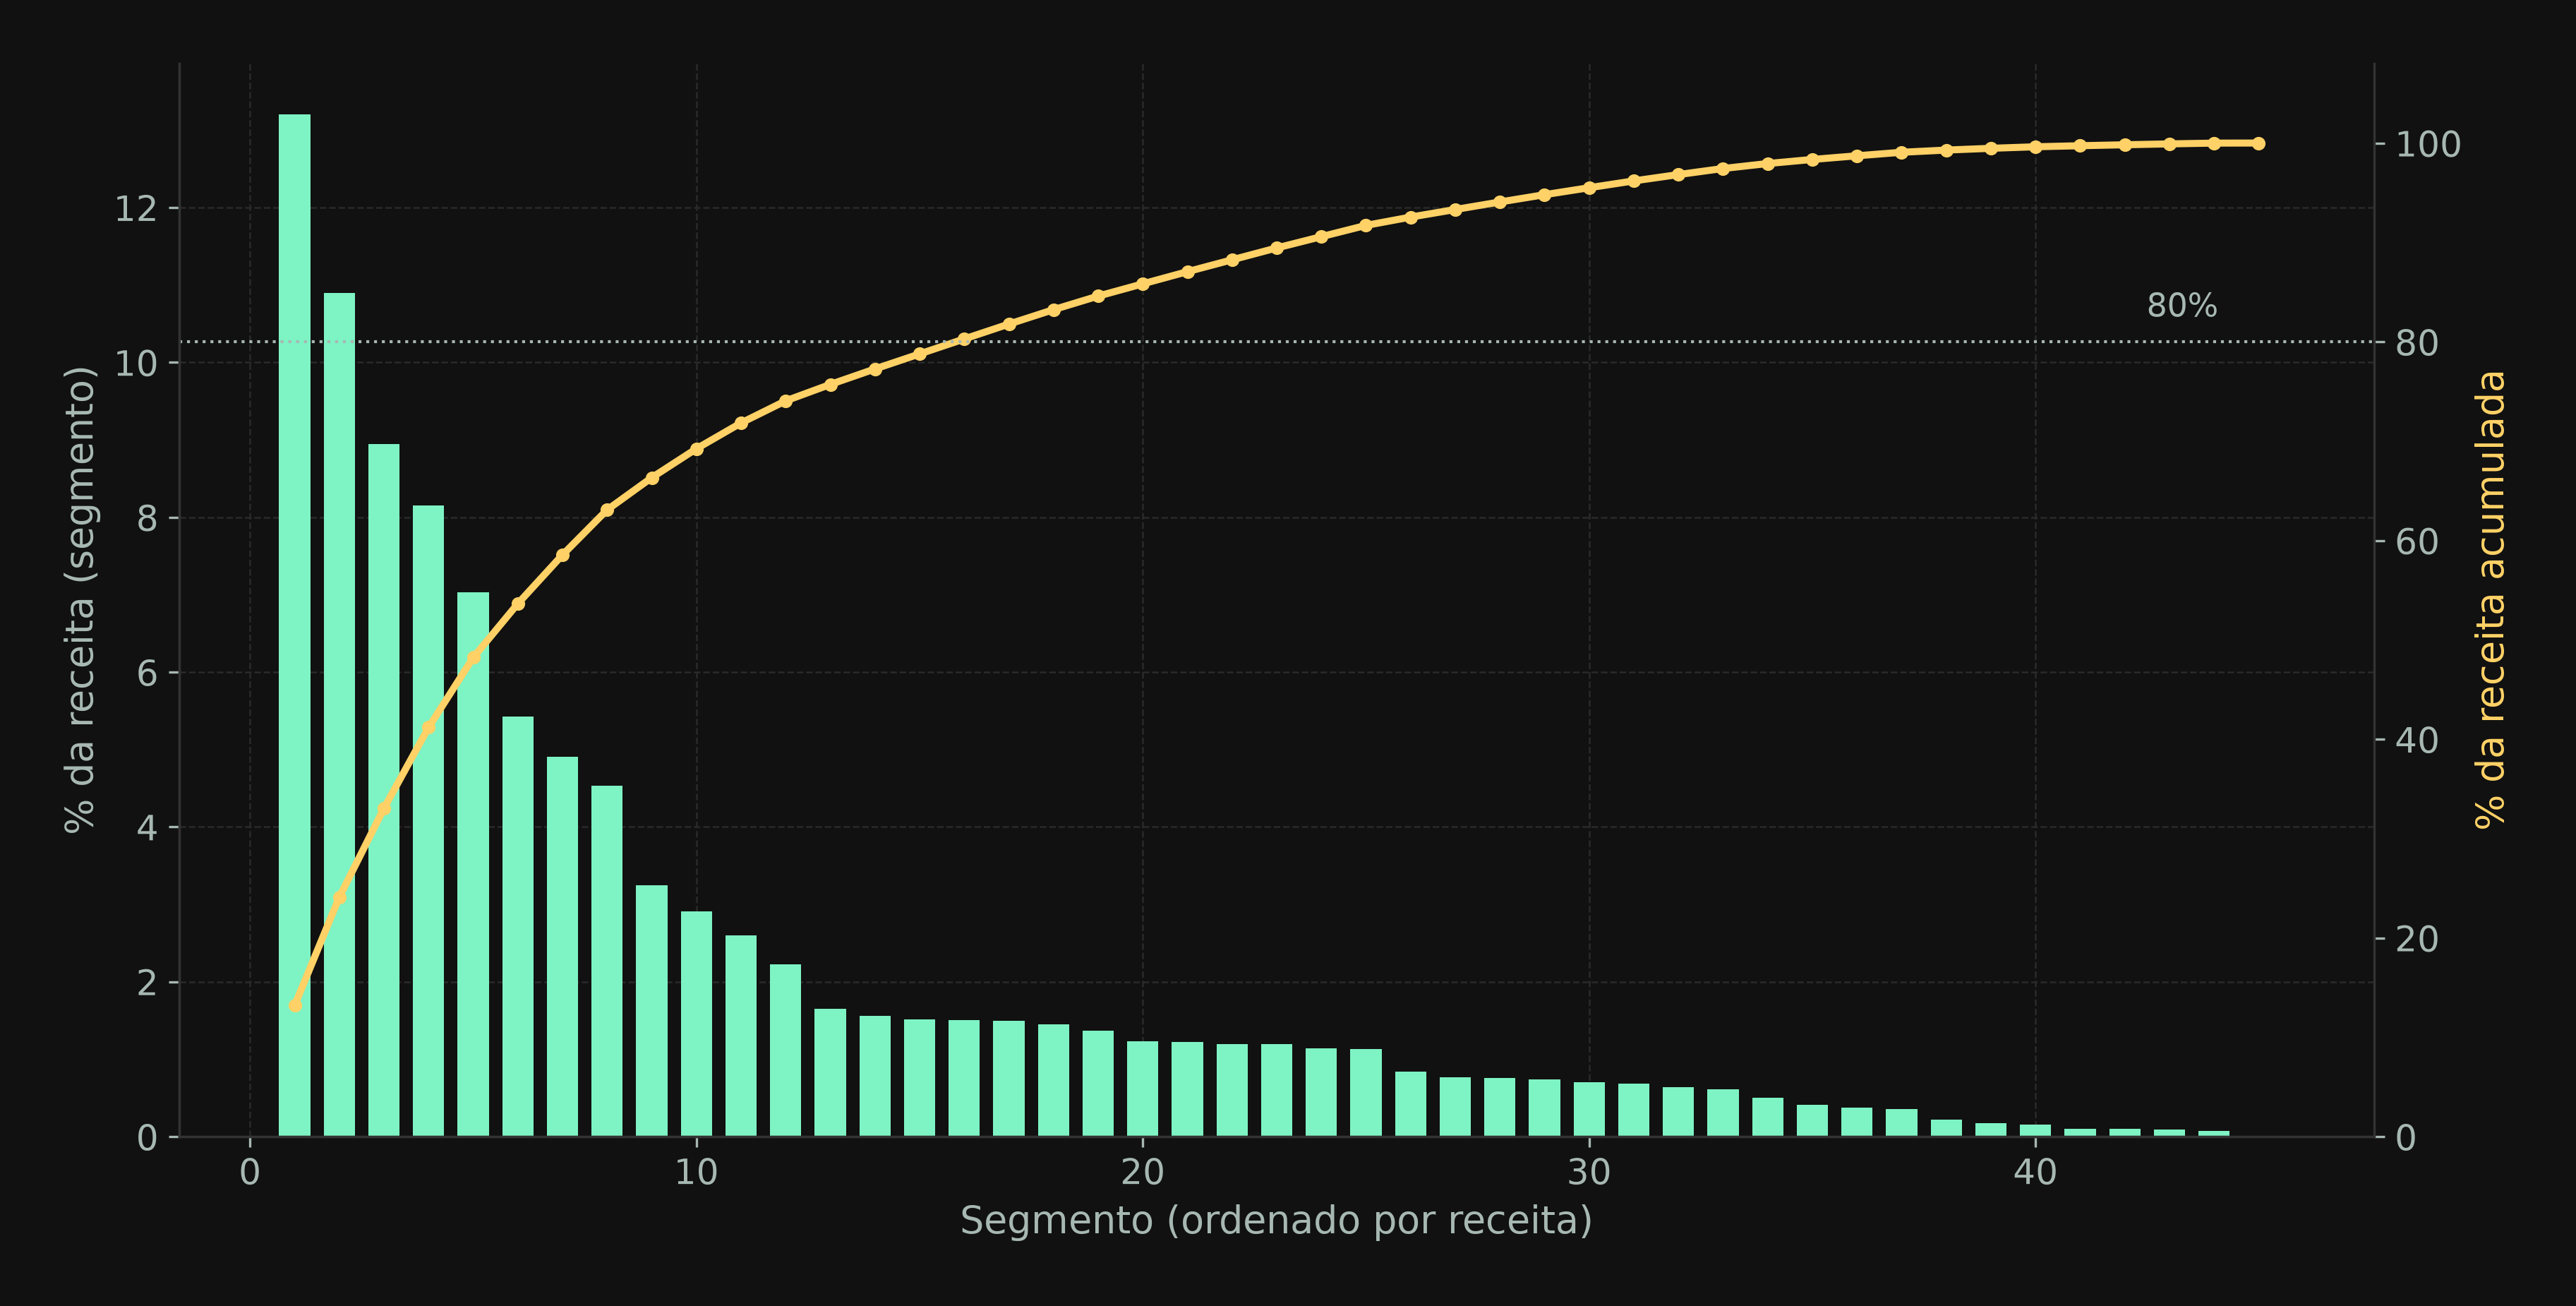

In [16]:
pareto = pd.read_csv(CLUSTER / '2.segmentacao_hibrida' / 'segmentos_pareto.csv')
n80 = int((pareto['receita_pct_acumulado'] < 80).sum() + 1)
print(f"{n80} de {len(pareto)} segmentos cobrem 80% da receita total")
Image(filename=FIGS / 'fig5_pareto_segmentos.png', width=950)

Como a receita se distribui entre famílias dentro de cada cluster — útil para ver se a concentração em poucas famílias (vista acima, na base inteira) se repete dentro de cada cluster individualmente ou muda de perfil.


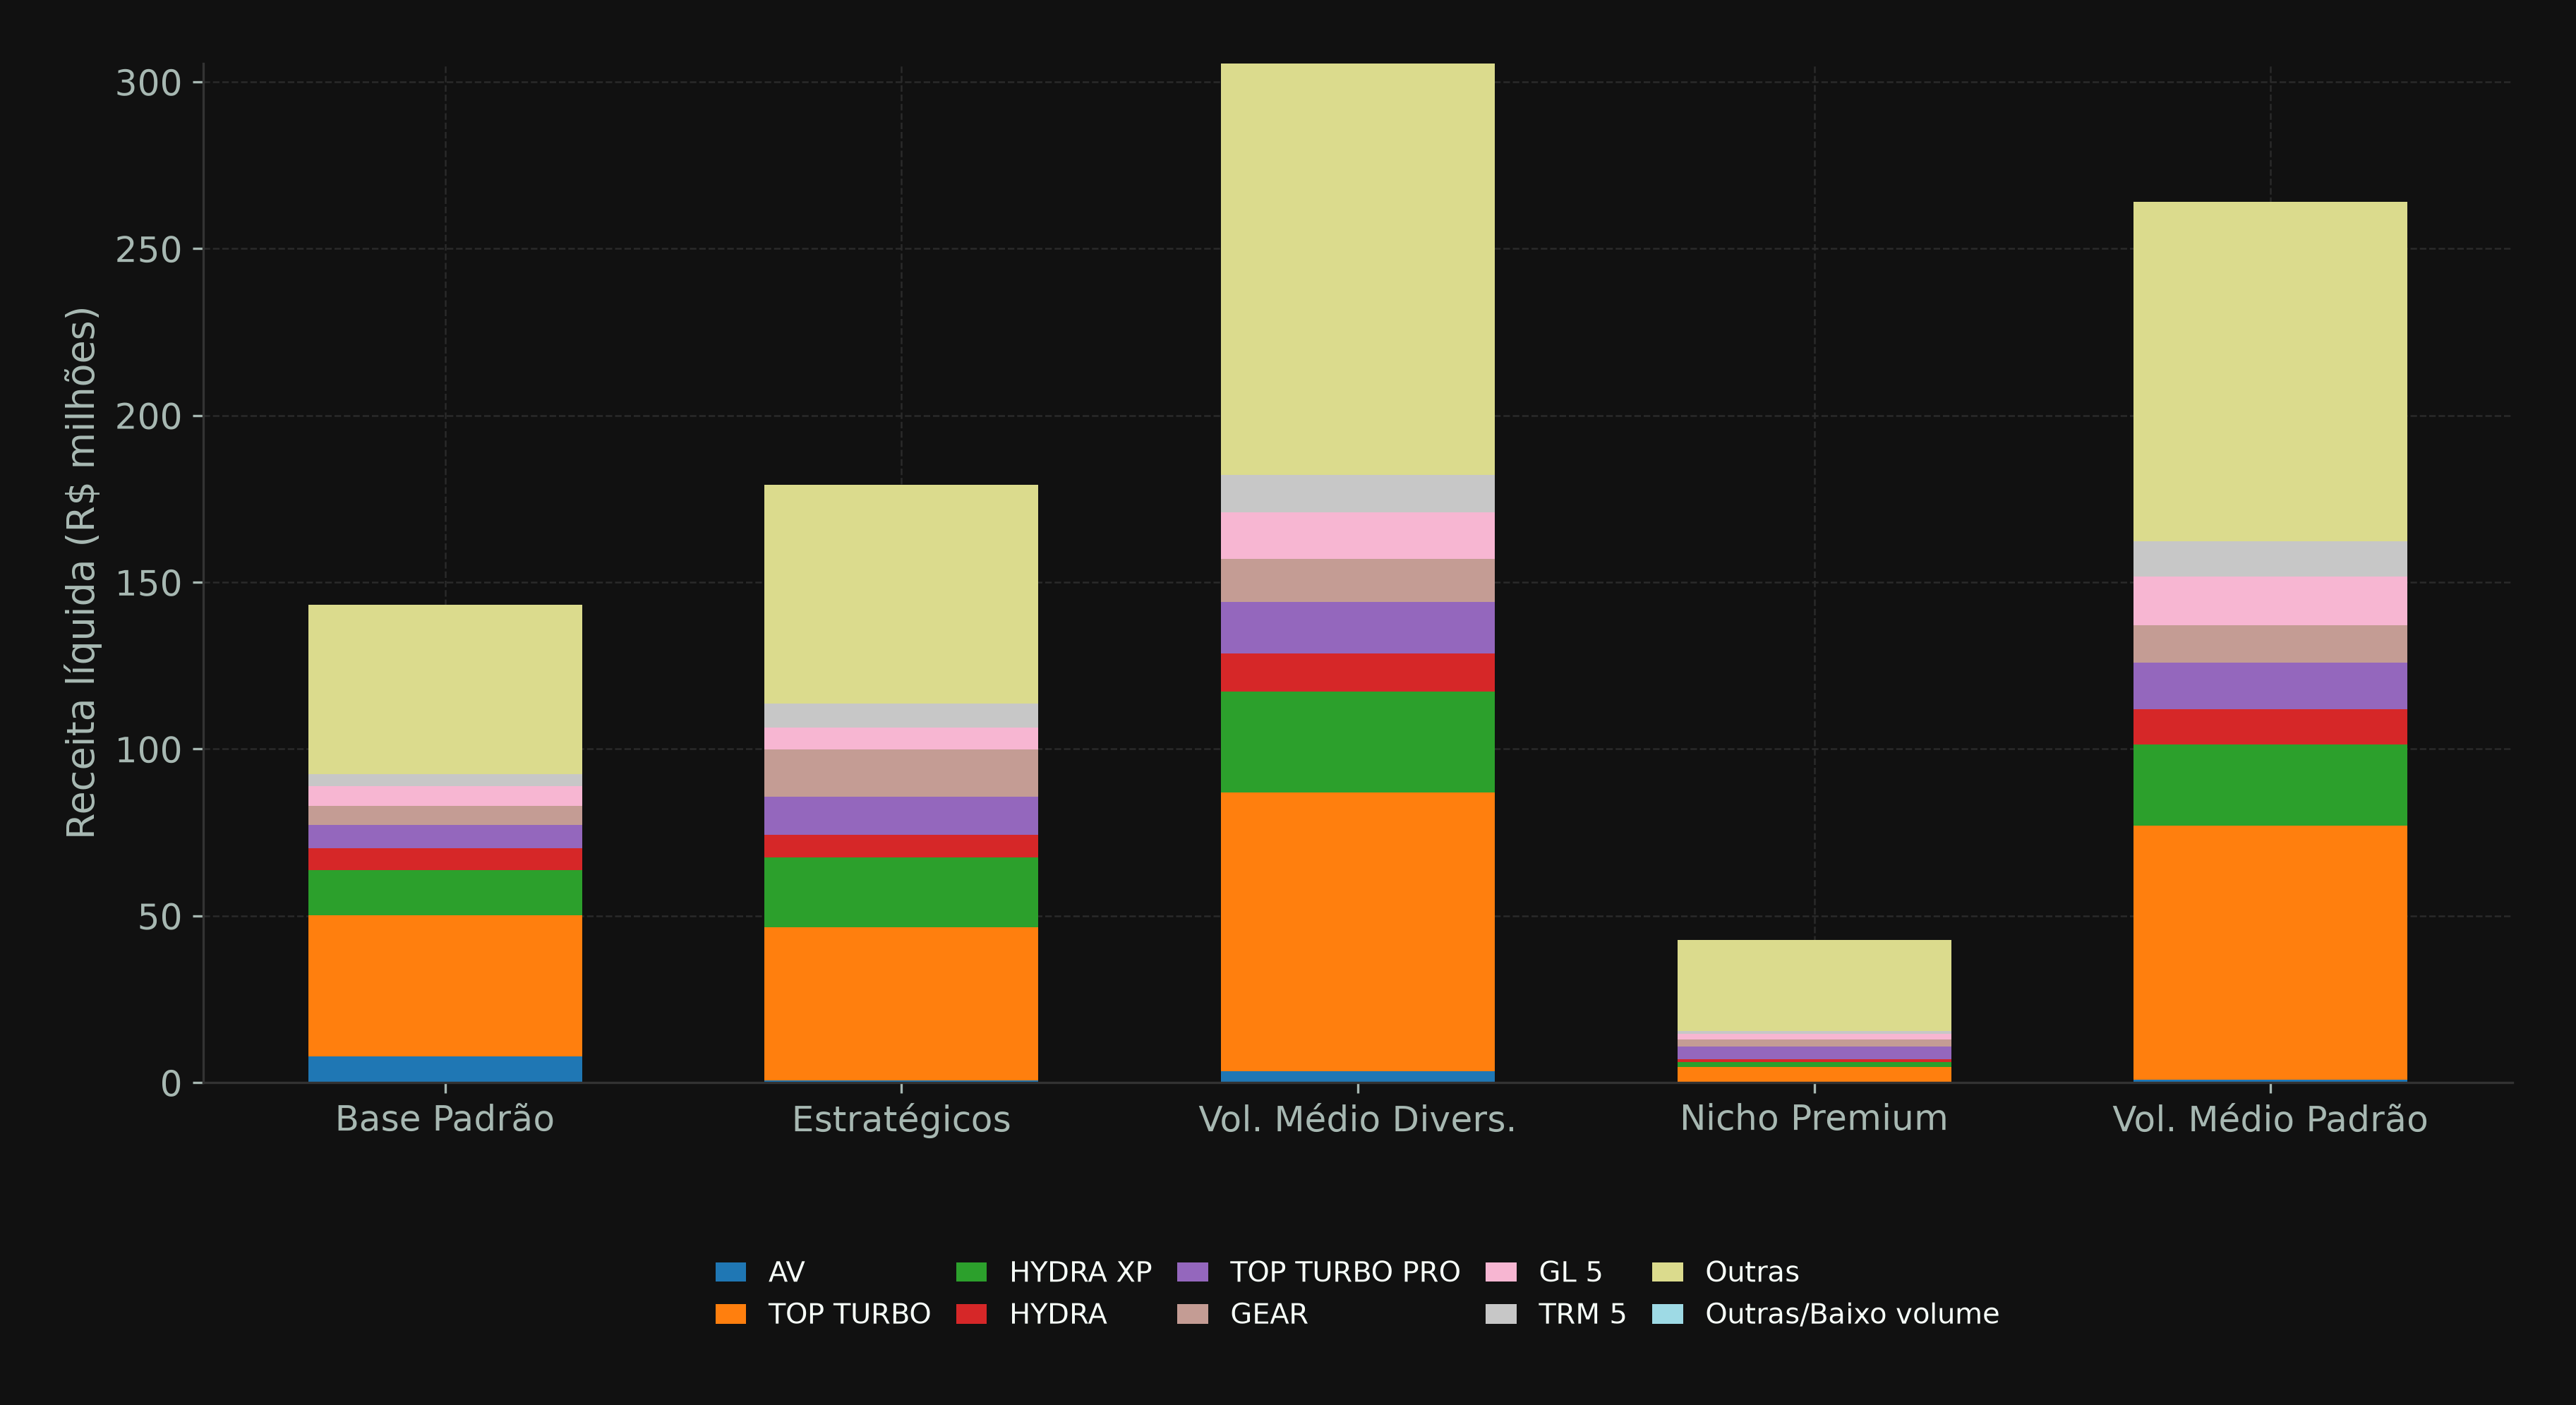

In [17]:
Image(filename=FIGS / 'fig11_receita_cluster_familia.png', width=950)


## 7. Limitações e cuidados

- **Nomes de cluster são sugestões**, baseadas nos perfis numéricos reais, mas não validadas com o
  time comercial — tratar como hipótese de trabalho, não como taxonomia final.
- **Silhueta de 0,30 é "aceitável", não "excelente"** — os 5 clusters têm alguma sobreposição real
  (visível na projeção PCA da seção 5); é o trade-off esperado ao priorizar granularidade comercial
  sobre separação estatística máxima.
- **Clusters podem mudar com o tempo** — comportamento de compra não é estático. Recomenda-se
  reprocessar a segmentação periodicamente (sugestão: trimestral) e comparar a composição dos clusters
  entre execuções.
- **Duas células da matriz híbrida** (cluster 1 × GL 5, cluster 1 × AV) não têm frequência dominante
  calculada — ver a explicação na seção 6.

## 8. Próximos passos

1. Validar os 5 clusters e os nomes sugeridos com o time comercial.
2. Implementar a tabela cluster × família como referência operacional de pricing.
3. Reprocessar a segmentação trimestralmente e monitorar estabilidade dos clusters.

## Anexo — arquivos gerados nesta análise

`outputs/` está organizado por etapa da análise: `1. EDA/`, `2. Clusterização/` (este projeto) e,
futuramente, `3.Elasticidade/`.

| Arquivo | Conteúdo |
|---|---|
| `docs/README.md` | Documentação consolidada do projeto: linhagem dos dados, dicionário, metodologia |
| `notebooks/1.EDA_Kmeans.ipynb` | Exploração, classificação de movimentos, reconciliação financeira, dataset agregado por cliente |
| `notebooks/2.Kmeans.ipynb` | Os 5 testes de clusterização, do k=2 inicial ao Teste 5 final |
| `notebooks/4.Segmentacao-Hibrida.ipynb` | Cruzamento cluster × família × frequência |
| `notebooks/7.Relatorio-Tecnico.ipynb` | Este relatório |
| `outputs/1. EDA/` | Dataset agregado por cliente e artefatos de reconciliação |
| `outputs/2. Clusterização/clusterizacao-vibra-lubrax.xlsx` | Todos os resultados consolidados em 9 abas |
| `outputs/2. Clusterização/segmentacao_clientes_kmeans.csv` | Segmentação final (cliente → cluster) |
| `outputs/2. Clusterização/1.Kmeans_testes/` | Artefatos de cada um dos 5 testes (auditoria/comparação) |
| `outputs/2. Clusterização/2.segmentacao_hibrida/` | Matriz cluster×família, Pareto |
| `outputs/2. Clusterização/3.relatorios/` | Este relatório em HTML |
| `outputs/2. Clusterização/4.apresentacao/` | Figuras usadas neste relatório e na apresentação |
| `outputs/2. Clusterização/5.Figures/` | Figuras de diagnóstico do modelo final (silhueta, PCA, boxplot) |
| `outputs/2. Clusterização/4.apresentacao/slides/Segmentacao-Clientes-Vibra-Lubrax.html` | Apresentação para consultor comercial e cliente |